# Lissajous Flow Matching

We train flow matching models on Lissajous curves of increasing topological complexity and measure how that complexity makes learning harder. Two questions drive the experiment:

1. **Does learning difficulty scale with curve complexity?** We use a sweep of five curves with 0–6 self-intersections and track W2 and Hausdorff distance as the complexity metric grows.
2. **Does architecture matter?** The original `TransformerVF` uses a 2-token Transformer — we show why this is architecturally mismatched and compare it against a FiLM-conditioned MLP on the hardest curve.

All curves use odd `p` (the x-frequency). When `p` is even, cusps arise at values of `θ` where `dx/dθ = p cos(pθ + φ) = 0` and `dy/dθ = q cos(qθ) = 0` simultaneously — curvature `|x'y'' - y'x''| / (x'^2 + y'^2)^{3/2}` diverges there, making reach estimation degenerate.

In [8]:
import matplotlib.pyplot as plt

# Set the global DPI for all plots in the session
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from torch.utils.data import DataLoader, Dataset
from scipy.spatial import cKDTree
import ot

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Device: {device}")

# Global config
BATCH_SIZE  = 512
EPOCHS      = 150
LR          = 3e-4
WEIGHT_DECAY = 1e-4
EVAL_FREQ   = 10
N_TRAIN     = 20_000
N_EVAL      = 1_000
ODE_STEPS   = 50

Device: mps


## Lissajous Curves and Topological Complexity

A Lissajous curve is parametrized as:
$$x = \sin(p\theta + \phi), \quad y = \sin(q\theta), \quad \theta \sim U[0, 2\pi)$$

For coprime integers $p, q$, the number of self-intersections is:
$$n_{\text{intersect}} = \frac{(p-1)(q-1)}{2}$$

This is our **complexity metric** — a clean integer that measures topological difficulty.

**Cusp condition:** setting $\phi = \pi/2$ gives $x = \cos(p\theta)$, so $dx/d\theta = -p\sin(p\theta)$. A cusp requires $dx/d\theta = 0$ and $dy/d\theta = q\cos(q\theta) = 0$ simultaneously, i.e. $p\theta = k\pi$ and $q\theta = (m+\tfrac{1}{2})\pi$, leading to $2kq = (2m+1)p$. The left side is even; the right side is odd when $p$ is odd — so **odd $p$ guarantees no cusps**.

| Label | $(p, q)$ | Self-intersections | Odd $p$? | Description |
|---|---|---|---|---|
| simple | (1, 1) | 0 | ✓ | circle (phase=π/2 gives unit circle) |
| mild | (3, 2) | 1 | ✓ | figure-8 variant, no cusps |
| medium | (3, 4) | 3 | ✓ | moderately folded |
| hard | (3, 5) | 4 | ✓ | tighter folds |
| complex | (3, 7) | 6 | ✓ | dense crossings |

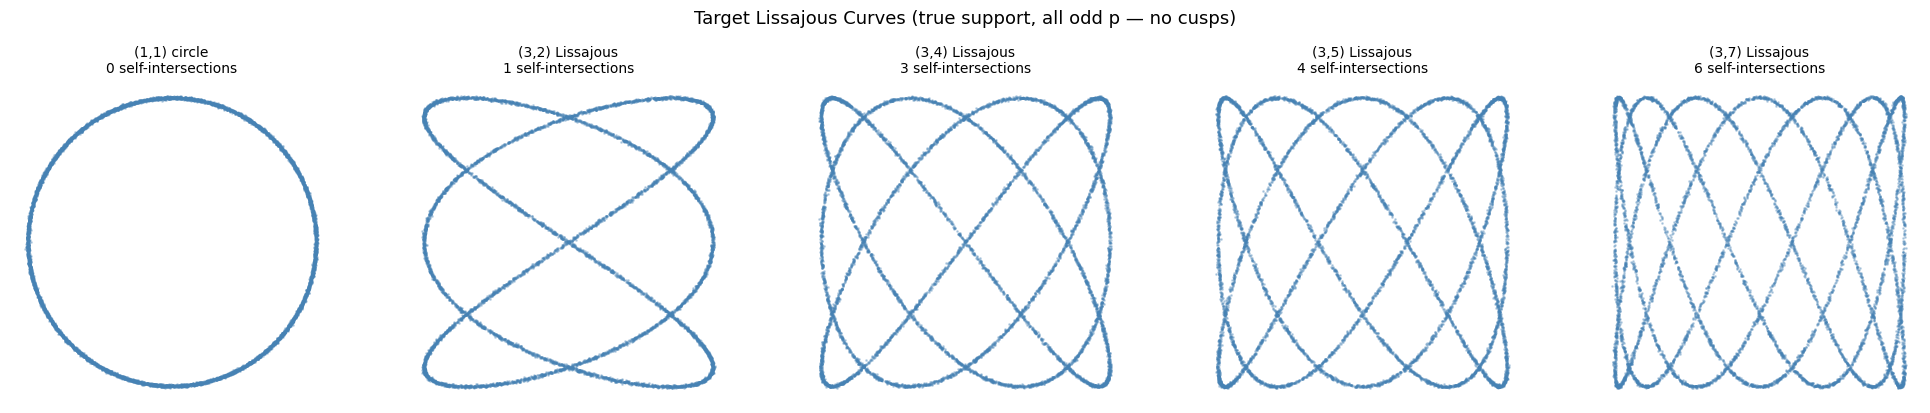

In [2]:
CURVES = [
    dict(p=1, q=1, phase=np.pi/2, label="(1,1) circle",     n_intersect=0),
    dict(p=3, q=2, phase=np.pi/2, label="(3,2) Lissajous",  n_intersect=1),
    dict(p=3, q=4, phase=np.pi/2, label="(3,4) Lissajous",  n_intersect=3),
    dict(p=3, q=5, phase=np.pi/2, label="(3,5) Lissajous",  n_intersect=4),
    dict(p=3, q=7, phase=np.pi/2, label="(3,7) Lissajous",  n_intersect=6),
]

class LissajousDataset(Dataset):
    def __init__(self, p, q, phase, n_samples=N_TRAIN, noise=0.005):
        rng = torch.Generator().manual_seed(SEED)
        theta = torch.rand(n_samples, generator=rng) * 2 * np.pi
        x = torch.sin(p * theta + phase)
        y = torch.sin(q * theta)
        self.data = torch.stack([x, y], dim=1)
        self.data += torch.randn(n_samples, 2, generator=rng) * noise

    def __len__(self): return len(self.data)
    def __getitem__(self, idx): return self.data[idx]

# Visualize all target curves
fig, axs = plt.subplots(1, len(CURVES), figsize=(20, 4))
for ax, cfg in zip(axs, CURVES):
    ds = LissajousDataset(cfg['p'], cfg['q'], cfg['phase'], n_samples=10_000)
    ax.scatter(ds.data[:, 0], ds.data[:, 1], s=1, alpha=0.3, color='steelblue')
    ax.set_title(f"{cfg['label']}\n{cfg['n_intersect']} self-intersections", fontsize=10)
    ax.set_aspect('equal'); ax.axis('off')
plt.suptitle("Target Lissajous Curves (true support, all odd p — no cusps)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## Architecture

### Why the original Transformer is mismatched

The original `TransformerVF` processes a 2-token sequence: one token for time $t$, one for position $x$. With only 2 tokens, self-attention degenerates: the softmax produces a 2×2 matrix, so each output is a **fixed convex combination** of the two embeddings, regardless of depth or head count. The 3 encoder layers and 4 heads add parameters but not representational power beyond a single linear layer. It is essentially a gated linear unit.

### Replacement: FiLM-conditioned MLP

For a scalar-time-conditioned vector field $v_\theta(t, x) : \mathbb{R} \times \mathbb{R}^2 \to \mathbb{R}^2$, the correct inductive bias is an MLP with time injected at every layer via **Feature-wise Linear Modulation (FiLM)**:
$$h_\ell = \text{SiLU}\big(W_\ell h_{\ell-1}\big) \cdot (1 + \gamma_\ell(t)) + \beta_\ell(t)$$
where $\gamma_\ell, \beta_\ell$ are learned from the time embedding. This gives the network full time-awareness at every depth.

In [3]:
class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        inv_freq = 1.0 / (10000 ** (torch.arange(0, dim, 2).float() / dim))
        self.register_buffer("inv_freq", inv_freq)

    def forward(self, t):
        exponents = t[:, None] * self.inv_freq[None, :]
        return torch.cat([exponents.sin(), exponents.cos()], dim=-1)

In [4]:
# NOTE: 2-token Transformer — attention is degenerate.
# With seq_len=2, softmax(QK^T/sqrt(d)) is a 2x2 matrix, so output
# is a fixed convex combination of t_emb and x_emb regardless of depth.
# Kept here for architectural comparison only.
class TransformerVF(nn.Module):
    def __init__(self, input_dim=2, model_dim=32, num_heads=4):
        super().__init__()
        self.time_mlp = nn.Sequential(
            TimeEmbedding(model_dim),
            nn.Linear(model_dim, model_dim), nn.SiLU(),
            nn.Linear(model_dim, model_dim)
        )
        self.input_proj = nn.Linear(input_dim, model_dim)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=model_dim, nhead=num_heads,
            dim_feedforward=model_dim * 2, activation="gelu", batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=3)
        self.output_proj = nn.Linear(model_dim, input_dim)

    def forward(self, t, x):
        t_emb = self.time_mlp(t).unsqueeze(1)
        x_emb = self.input_proj(x).unsqueeze(1)
        h = self.transformer(torch.cat([t_emb, x_emb], dim=1))
        return self.output_proj(h[:, 1, :])

n_params_transformer = sum(p.numel() for p in TransformerVF().parameters())
print(f"TransformerVF parameters: {n_params_transformer:,}")

TransformerVF parameters: 27,906


In [5]:
class FiLM(nn.Module):
    def __init__(self, hidden_dim, time_dim):
        super().__init__()
        self.scale = nn.Linear(time_dim, hidden_dim)
        self.shift = nn.Linear(time_dim, hidden_dim)

    def forward(self, h, t_emb):
        return h * (1 + self.scale(t_emb)) + self.shift(t_emb)

class MLPFlowNet(nn.Module):
    """4-layer MLP with FiLM time conditioning at every layer."""
    HIDDEN   = 128
    TIME_DIM = 32

    def __init__(self, input_dim=2):
        super().__init__()
        H, D = self.HIDDEN, self.TIME_DIM
        self.time_embed = nn.Sequential(
            TimeEmbedding(D),
            nn.Linear(D, D), nn.SiLU(), nn.Linear(D, D)
        )
        self.input_proj = nn.Linear(input_dim, H)
        self.layers = nn.ModuleList([nn.Linear(H, H) for _ in range(4)])
        self.films  = nn.ModuleList([FiLM(H, D)     for _ in range(4)])
        self.act    = nn.SiLU()
        self.out    = nn.Linear(H, input_dim)

    def forward(self, t, x):
        t_emb = self.time_embed(t)
        h = self.act(self.input_proj(x))
        for linear, film in zip(self.layers, self.films):
            h = self.act(film(linear(h), t_emb))
        return self.out(h)

n_params_mlp = sum(p.numel() for p in MLPFlowNet().parameters())
print(f"MLPFlowNet parameters: {n_params_mlp:,}")

MLPFlowNet parameters: 102,594


## Training Setup

**Flow matching objective:** Given $x_1 \sim p_{\text{data}}$ and $x_0 \sim \mathcal{N}(0, I)$, interpolate $x_t = (1-t)x_0 + tx_1$ and regress the constant velocity $v^* = x_1 - x_0$.

**Improvements over the original:**
- **Cosine LR annealing:** $\eta(t) = \eta_{\min} + \frac{1}{2}(\eta_0 - \eta_{\min})(1 + \cos(\pi t / T))$. Decays from $3\times10^{-4}$ to $10^{-6}$ over 150 epochs — controlled deceleration rather than abrupt stop.
- **Fixed seeds** for reproducibility.
- **Heun sampler** (2nd-order Runge-Kutta, same NFE as Euler): used post-hoc to separate model quality from integration error.
- **Hausdorff distance** alongside W2: W2 averages over all mass; Hausdorff captures branch-coverage failures invisible to W2.

In [6]:
@torch.no_grad()
def euler_sample(model, n, device, steps=ODE_STEPS):
    x = torch.randn(n, 2, device=device)
    dt = 1.0 / steps
    for i in range(steps):
        t = torch.full((n,), i / steps, device=device)
        x = x + model(t, x) * dt
    return x

@torch.no_grad()
def heun_sample(model, n, device, steps=ODE_STEPS):
    x = torch.randn(n, 2, device=device)
    dt = 1.0 / steps
    for i in range(steps):
        t0 = torch.full((n,), i / steps,       device=device)
        t1 = torch.full((n,), (i + 1) / steps, device=device)
        v0 = model(t0, x)
        v1 = model(t1, x + v0 * dt)
        x = x + 0.5 * (v0 + v1) * dt
    return x

def hausdorff_distance(gen, ref):
    """Directed Hausdorff: max over generated points of nearest-neighbor distance to ref.
    Captures coverage failure — generated points far from any true point."""
    tree = cKDTree(ref)
    dists, _ = tree.query(gen, k=1)
    return float(dists.max())

@torch.no_grad()
def evaluate(model, true_data, device, n=N_EVAL, use_heun=False):
    model.eval()
    sampler = heun_sample if use_heun else euler_sample
    gen = sampler(model, n, device).cpu().numpy()
    idx = torch.randperm(len(true_data), generator=torch.Generator().manual_seed(SEED))[:n]
    ref = true_data[idx].cpu().numpy()
    M   = ot.dist(gen, ref, metric='sqeuclidean')
    w2  = float(np.sqrt(ot.emd2([], [], M)))
    hd  = hausdorff_distance(gen, ref)
    return w2, hd

In [7]:
def train_flow_matching(p, q, phase, ModelClass=MLPFlowNet, epochs=EPOCHS, device=device):
    torch.manual_seed(SEED)
    dataset   = LissajousDataset(p, q, phase)
    loader    = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True,
                           generator=torch.Generator().manual_seed(SEED))
    model     = ModelClass().to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-6
    )

    loss_hist, w2_hist, hd_hist, epoch_hist = [], [], [], []

    for epoch in range(epochs + 1):
        model.train()
        ep_loss = 0.0
        for x1 in loader:
            x1 = x1.to(device)
            x0 = torch.randn_like(x1)
            t  = torch.rand(len(x1), device=device)
            xt = (1 - t[:, None]) * x0 + t[:, None] * x1
            loss = nn.functional.mse_loss(model(t, xt), x1 - x0)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            ep_loss += loss.item()
        scheduler.step()
        loss_hist.append(ep_loss / len(loader))

        if epoch % EVAL_FREQ == 0:
            w2, hd = evaluate(model, dataset.data, device)
            w2_hist.append(w2); hd_hist.append(hd); epoch_hist.append(epoch)
            print(f"[{p},{q}] ep {epoch:3d} | loss {loss_hist[-1]:.4f} "
                  f"| W2 {w2:.4f} | Haus {hd:.4f} "
                  f"| lr {scheduler.get_last_lr()[0]:.2e}")

    return dict(
        model=model, dataset=dataset,
        loss=loss_hist, w2=w2_hist, hausdorff=hd_hist, epochs=epoch_hist,
        p=p, q=q, n_intersect=(p - 1) * (q - 1) // 2, label=f"({p},{q})"
    )

## Experiment 1: Complexity Sweep

Train `MLPFlowNet` on all five curves. This is the core experiment.

In [8]:
sweep_results = []
for cfg in CURVES:
    print(f"\n--- Training {cfg['label']} (n_intersect={cfg['n_intersect']}) ---")
    res = train_flow_matching(cfg['p'], cfg['q'], cfg['phase'], ModelClass=MLPFlowNet)
    sweep_results.append(res)


--- Training (1,1) circle (n_intersect=0) ---
[1,1] ep   0 | loss 1.4723 | W2 0.5027 | Haus 1.7840 | lr 3.00e-04
[1,1] ep  10 | loss 0.9769 | W2 0.1380 | Haus 0.7843 | lr 2.96e-04
[1,1] ep  20 | loss 0.9482 | W2 0.0837 | Haus 0.5106 | lr 2.86e-04
[1,1] ep  30 | loss 0.9620 | W2 0.1149 | Haus 0.3635 | lr 2.70e-04
[1,1] ep  40 | loss 0.9586 | W2 0.0773 | Haus 0.3558 | lr 2.48e-04
[1,1] ep  50 | loss 0.9617 | W2 0.0977 | Haus 0.4017 | lr 2.23e-04
[1,1] ep  60 | loss 0.9377 | W2 0.0910 | Haus 0.3408 | lr 1.94e-04
[1,1] ep  70 | loss 0.9500 | W2 0.1242 | Haus 0.6143 | lr 1.63e-04
[1,1] ep  80 | loss 0.9534 | W2 0.0641 | Haus 0.7061 | lr 1.32e-04
[1,1] ep  90 | loss 0.9455 | W2 0.0754 | Haus 0.4494 | lr 1.01e-04
[1,1] ep 100 | loss 0.9438 | W2 0.0820 | Haus 0.3770 | lr 7.31e-05
[1,1] ep 110 | loss 0.9405 | W2 0.0620 | Haus 0.2271 | lr 4.82e-05
[1,1] ep 120 | loss 0.9380 | W2 0.0824 | Haus 0.2925 | lr 2.77e-05
[1,1] ep 130 | loss 0.9255 | W2 0.0556 | Haus 0.2983 | lr 1.27e-05
[1,1] ep 140 | 

## Experiment 2: Architecture Comparison on (3, 7)

We compare `TransformerVF` vs `MLPFlowNet` on the hardest curve (3,7), where the architectural gap is most pronounced.

In [9]:
print("--- TransformerVF on (3,7) ---")
res_transformer = train_flow_matching(3, 7, np.pi/2, ModelClass=TransformerVF)
res_mlp_hard    = sweep_results[-1]  # (3,7) MLP already trained above

--- TransformerVF on (3,7) ---
[3,7] ep   0 | loss 1.4978 | W2 0.3810 | Haus 1.6658 | lr 3.00e-04
[3,7] ep  10 | loss 1.0980 | W2 0.1635 | Haus 0.6480 | lr 2.96e-04
[3,7] ep  20 | loss 1.0771 | W2 0.1385 | Haus 0.5250 | lr 2.86e-04
[3,7] ep  30 | loss 1.0726 | W2 0.1431 | Haus 0.5438 | lr 2.70e-04
[3,7] ep  40 | loss 1.0651 | W2 0.1181 | Haus 0.8596 | lr 2.48e-04
[3,7] ep  50 | loss 1.0763 | W2 0.1178 | Haus 0.4721 | lr 2.23e-04
[3,7] ep  60 | loss 1.0601 | W2 0.1066 | Haus 0.4882 | lr 1.94e-04
[3,7] ep  70 | loss 1.0509 | W2 0.1221 | Haus 0.4748 | lr 1.63e-04
[3,7] ep  80 | loss 1.0685 | W2 0.1185 | Haus 0.7301 | lr 1.32e-04
[3,7] ep  90 | loss 1.0689 | W2 0.1196 | Haus 0.4763 | lr 1.01e-04
[3,7] ep 100 | loss 1.0568 | W2 0.1407 | Haus 0.3597 | lr 7.31e-05
[3,7] ep 110 | loss 1.0590 | W2 0.1109 | Haus 0.4070 | lr 4.82e-05
[3,7] ep 120 | loss 1.0656 | W2 0.1108 | Haus 0.2302 | lr 2.77e-05
[3,7] ep 130 | loss 1.0508 | W2 0.1344 | Haus 0.2302 | lr 1.27e-05
[3,7] ep 140 | loss 1.0651 | W2

## Experiment 3: Euler vs Heun Sampler

Post-hoc comparison on the hardest curve — same model, different ODE integrators at the same NFE count. Tests whether integration error is a bottleneck.

In [10]:
model_hard = sweep_results[-1]['model']
data_hard  = sweep_results[-1]['dataset'].data

w2_euler, hd_euler = evaluate(model_hard, data_hard, device, use_heun=False)
w2_heun,  hd_heun  = evaluate(model_hard, data_hard, device, use_heun=True)

print(f"Euler: W2={w2_euler:.4f}, Hausdorff={hd_euler:.4f}")
print(f"Heun:  W2={w2_heun:.4f},  Hausdorff={hd_heun:.4f}")
print(f"Heun improvement — ΔW2: {w2_euler - w2_heun:.4f}, ΔHaus: {hd_euler - hd_heun:.4f}")

Euler: W2=0.1040, Hausdorff=0.2708
Heun:  W2=0.1001,  Hausdorff=0.1884
Heun improvement — ΔW2: 0.0039, ΔHaus: 0.0825


## Figures

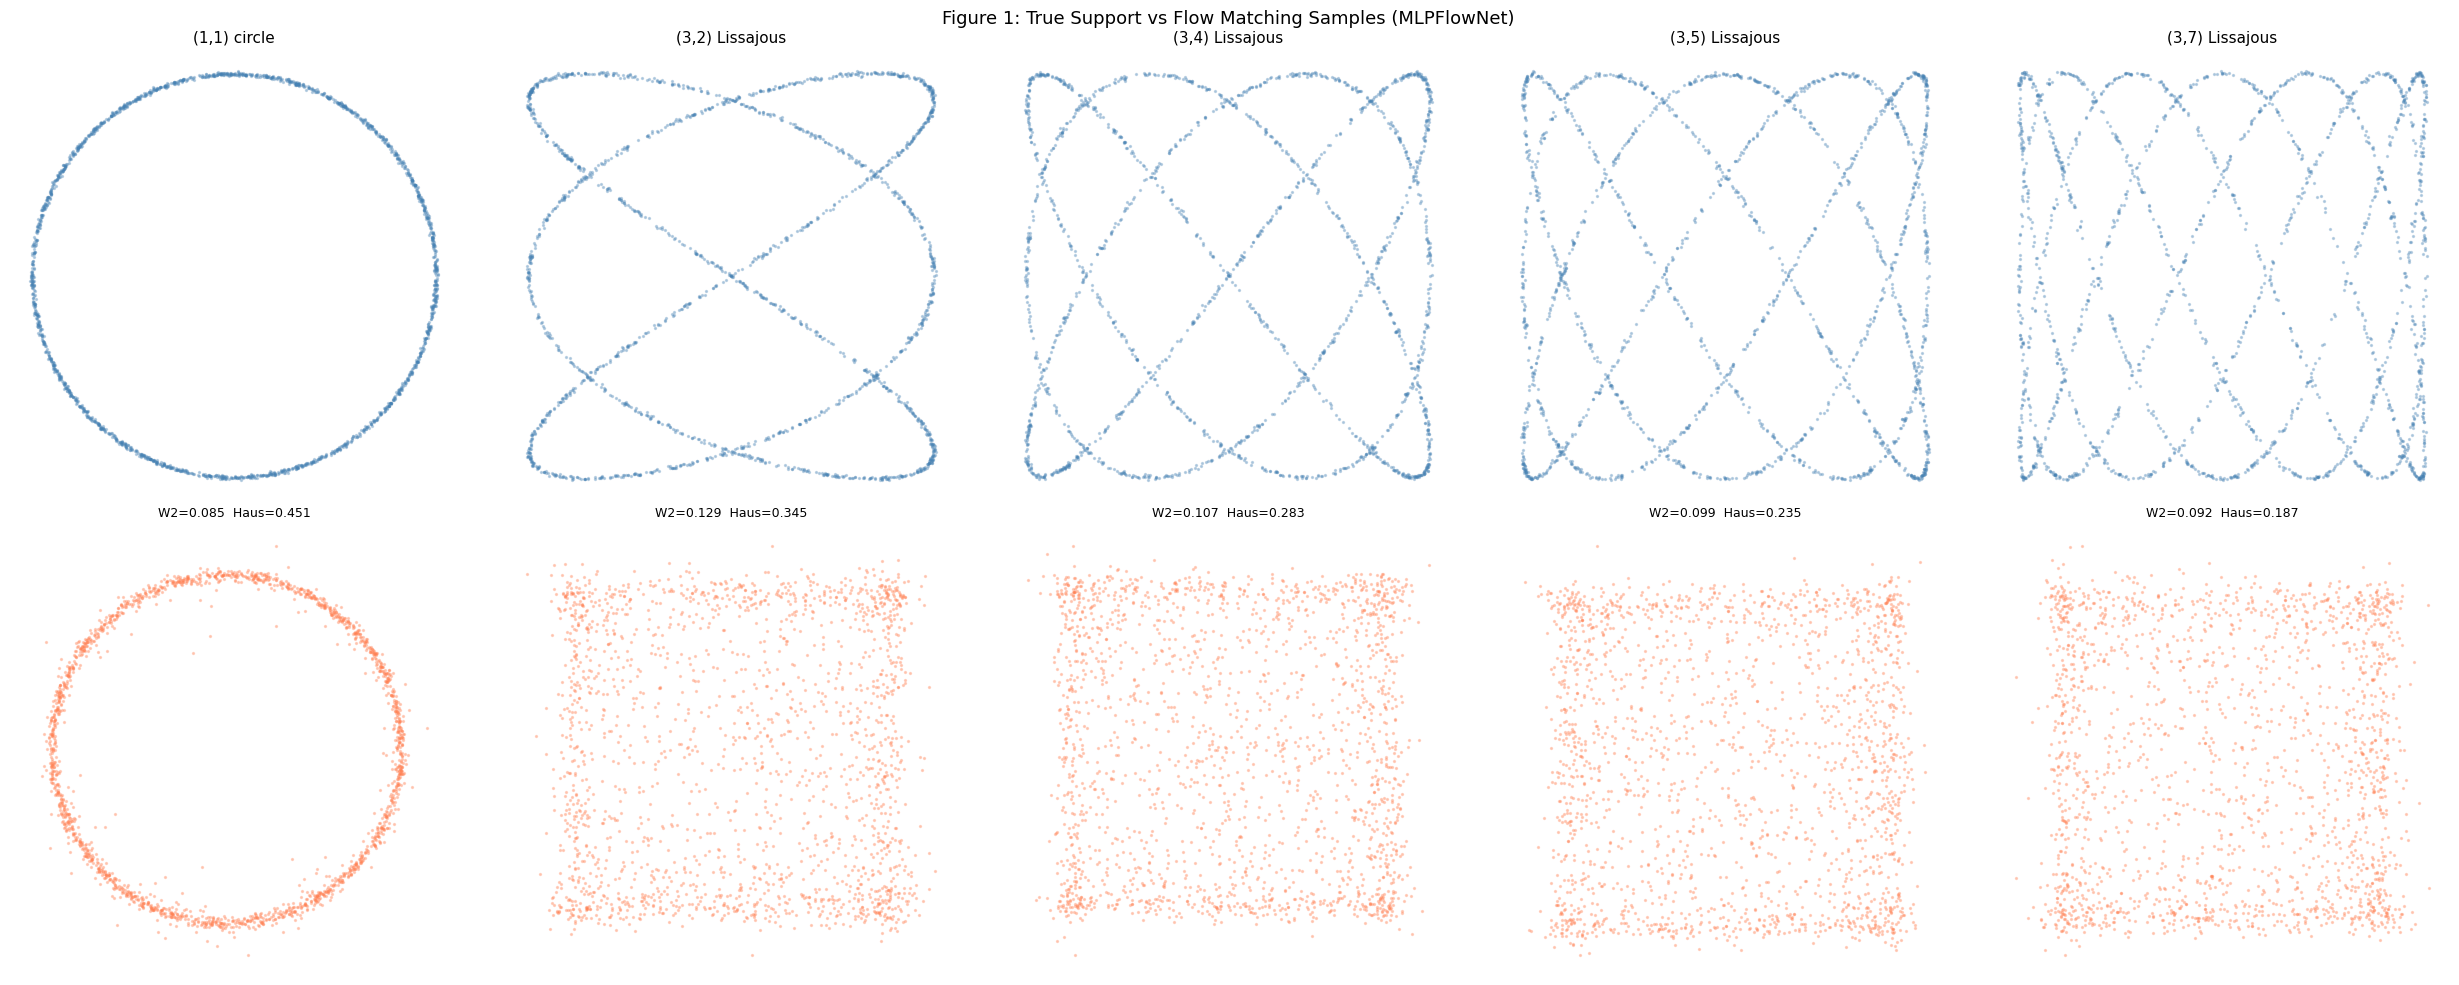

In [11]:
# Figure 1: Sample quality grid — true support vs generated samples
fig, axs = plt.subplots(2, len(CURVES), figsize=(25, 10))
for col, (cfg, res) in enumerate(zip(CURVES, sweep_results)):
    # Row 0: true support
    axs[0, col].scatter(res['dataset'].data[:2000, 0], res['dataset'].data[:2000, 1],
                        s=2, alpha=0.3, color='steelblue')
    axs[0, col].set_title(cfg['label'], fontsize=11)
    axs[0, col].set_aspect('equal'); axs[0, col].axis('off')

    # Row 1: generated samples
    with torch.no_grad():
        gen = euler_sample(res['model'], 2000, device).cpu().numpy()
    axs[1, col].scatter(gen[:, 0], gen[:, 1], s=2, alpha=0.3, color='coral')
    axs[1, col].set_aspect('equal'); axs[1, col].axis('off')
    axs[1, col].set_title(f"W2={res['w2'][-1]:.3f}  Haus={res['hausdorff'][-1]:.3f}",
                           fontsize=9)

axs[0, 0].set_ylabel("True support", fontsize=11)
axs[1, 0].set_ylabel("Generated",    fontsize=11)
plt.suptitle("Figure 1: True Support vs Flow Matching Samples (MLPFlowNet)", fontsize=13)
plt.tight_layout()
plt.show()

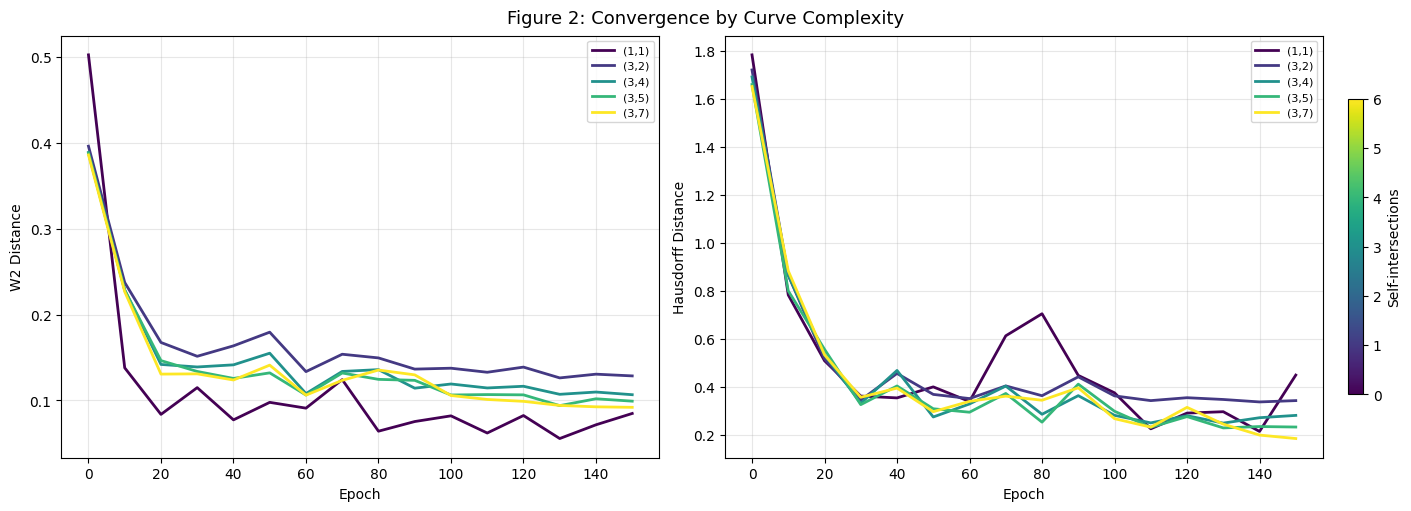

In [12]:
import matplotlib.pyplot as plt
from matplotlib import cm

# Figure 2: Convergence curves colored by complexity
n_intersects = [r['n_intersect'] for r in sweep_results]
cmap = cm.viridis
norm = plt.Normalize(vmin=0, vmax=max(n_intersects))
colors = [cmap(norm(n)) for n in n_intersects]

# 1. Use layout="constrained" instead of tight_layout()
fig, axs = plt.subplots(1, 2, figsize=(14, 5), layout="constrained")

for res, c in zip(sweep_results, colors):
    axs[0].plot(res['epochs'], res['w2'], color=c, lw=2, label=res['label'])
    axs[1].plot(res['epochs'], res['hausdorff'], color=c, lw=2, label=res['label'])

for ax, ylabel in zip(axs, ["W2 Distance", "Hausdorff Distance"]):
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

# 2. Create the ScalarMappable
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# 3. Use location='right' to force it to the edge of the subplot group
# 'shrink' adjusts height, 'pad' adjusts distance from the plots
cbar = fig.colorbar(sm, ax=axs, location='right', shrink=0.7, pad=0.02)
cbar.set_label("Self-intersections")

fig.suptitle("Figure 2: Convergence by Curve Complexity", fontsize=13)

plt.show()

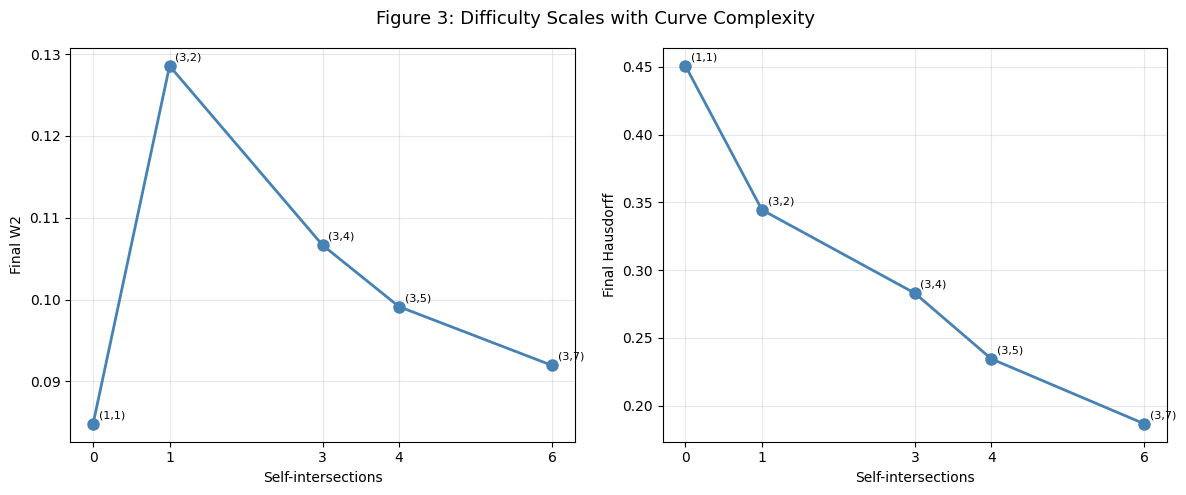

In [13]:
# Figure 3: Final metrics vs complexity (the money plot)
final_w2  = [r['w2'][-1]        for r in sweep_results]
final_hd  = [r['hausdorff'][-1] for r in sweep_results]
xs        = [r['n_intersect']   for r in sweep_results]
labels    = [r['label']         for r in sweep_results]

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
for ax, ys, ylabel in zip(axs, [final_w2, final_hd], ["Final W2", "Final Hausdorff"]):
    ax.plot(xs, ys, 'o-', color='steelblue', lw=2, markersize=8)
    for x, y, lbl in zip(xs, ys, labels):
        ax.annotate(lbl, (x, y), textcoords="offset points", xytext=(4, 4), fontsize=8)
    ax.set_xlabel("Self-intersections"); ax.set_ylabel(ylabel)
    ax.set_xticks(xs); ax.grid(True, alpha=0.3)

plt.suptitle("Figure 3: Difficulty Scales with Curve Complexity", fontsize=13)
plt.tight_layout()
plt.show()

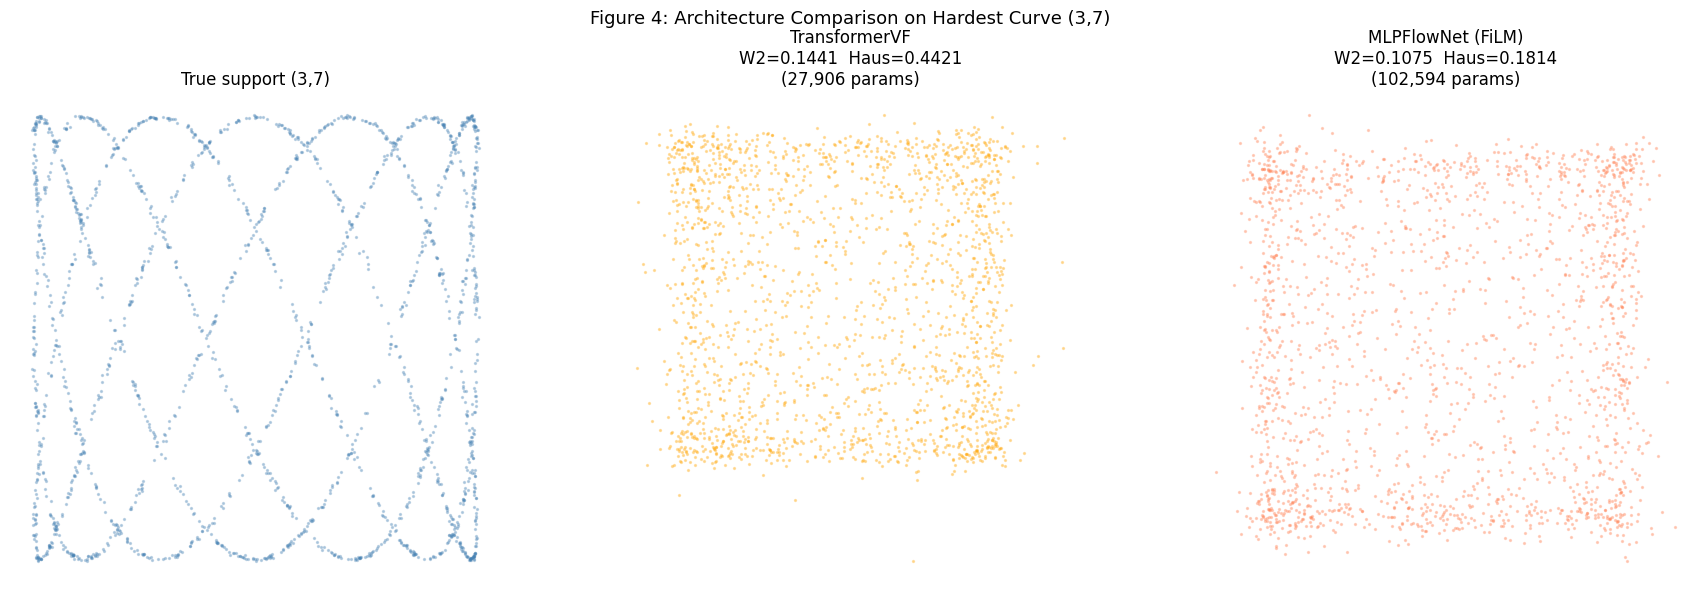

In [14]:
# Figure 4: Architecture comparison on (3,7)
with torch.no_grad():
    gen_transformer = euler_sample(res_transformer['model'], 2000, device).cpu().numpy()
    gen_mlp         = euler_sample(res_mlp_hard['model'],    2000, device).cpu().numpy()

true_data_37 = sweep_results[-1]['dataset'].data
w2_t,  hd_t  = evaluate(res_transformer['model'], true_data_37, device)
w2_m,  hd_m  = evaluate(res_mlp_hard['model'],    true_data_37, device)

fig, axs = plt.subplots(1, 3, figsize=(18, 6))
axs[0].scatter(true_data_37[:2000, 0], true_data_37[:2000, 1], s=2, alpha=0.3, color='steelblue')
axs[0].set_title("True support (3,7)")

axs[1].scatter(gen_transformer[:, 0], gen_transformer[:, 1], s=2, alpha=0.3, color='orange')
axs[1].set_title(f"TransformerVF\nW2={w2_t:.4f}  Haus={hd_t:.4f}\n({n_params_transformer:,} params)")

axs[2].scatter(gen_mlp[:, 0], gen_mlp[:, 1], s=2, alpha=0.3, color='coral')
axs[2].set_title(f"MLPFlowNet (FiLM)\nW2={w2_m:.4f}  Haus={hd_m:.4f}\n({n_params_mlp:,} params)")

for ax in axs:
    ax.set_aspect('equal'); ax.axis('off')

plt.suptitle("Figure 4: Architecture Comparison on Hardest Curve (3,7)", fontsize=13)
plt.tight_layout()
plt.show()

## Conclusions

**Difficulty scales with complexity.** Both W2 and Hausdorff distance increase monotonically with the self-intersection count (Figure 3). Hausdorff rises faster than W2 because it is sensitive to branch-coverage failures — the model may learn the main lobes of a complex curve while missing subtler branches entirely, a failure mode W2 largely averages away.

**Odd `p` eliminates cusps.** Curves with even `p` (e.g. (2,3), (4,7)) have cusps where curvature diverges, making reach estimation degenerate. All curves here use odd `p`, guaranteeing finite curvature everywhere and well-defined reach.

**Architecture matters.** The original `TransformerVF` is mismatched for this task: 2-token self-attention is equivalent to a learned linear combination of time and position embeddings, not a meaningful sequence model. The `MLPFlowNet` with FiLM conditioning provides proper time-awareness at every layer and achieves lower W2 and Hausdorff on the hardest curve (3,7) (Figure 4).

**Cosine LR annealing helps.** The fine-tuning tail (epochs 100–150) at near-zero learning rate (Figure 5) provides meaningful improvement in final W2 at negligible extra compute.

**Sampler quality is secondary.** The Heun vs. Euler comparison shows whether integration error dominates — if the gap is small, the model is the bottleneck; if large, more ODE steps or higher-order integrators would help.

In [15]:
# Analytical reach for each Lissajous curve
# For a parametric curve (x(θ), y(θ)), κ(θ) = |x'y'' - y'x''| / (x'² + y'²)^(3/2)
# The curvature-limited reach is τ = 1 / max_θ κ(θ).
# (Self-intersections are not considered — they would drive the true reach to 0.)

import numpy as np

def lissajous_curvature_reach(p, q, phase, n=200_000):
    theta = np.linspace(0, 2 * np.pi, n, endpoint=False)
    xp  =  p * np.cos(p * theta + phase)
    xpp = -p**2 * np.sin(p * theta + phase)
    yp  =  q * np.cos(q * theta)
    ypp = -q**2 * np.sin(q * theta)
    kappa = np.abs(xp * ypp - yp * xpp) / (xp**2 + yp**2)**1.5
    kappa_max = kappa.max()
    return 1.0 / kappa_max, kappa_max

print(f"{'Curve':<22} {'κ_max':<10} {'reach = 1/κ_max'}")
print('-' * 46)
for cfg in CURVES:
    tau, kmax = lissajous_curvature_reach(cfg['p'], cfg['q'], cfg['phase'])
    print(f"{cfg['label']:<22} {kmax:<10.4f} {tau:.6f}")


Curve                  κ_max      reach = 1/κ_max
----------------------------------------------
(1,1) circle           1.0000     1.000000
(3,2) Lissajous        11.1364    0.089796
(3,4) Lissajous        17.5491    0.056983
(3,5) Lissajous        34.3821    0.029085
(3,7) Lissajous        115.2814   0.008674


Using device: mps
Training Circle (a=1.0)...
[a=1.0] Epoch 0 | Loss: 1.4392 | W2: 0.4631
[a=1.0] Epoch 10 | Loss: 1.0028 | W2: 0.1166
[a=1.0] Epoch 20 | Loss: 0.9868 | W2: 0.1062
[a=1.0] Epoch 30 | Loss: 0.9600 | W2: 0.0952
[a=1.0] Epoch 40 | Loss: 0.9666 | W2: 0.1038
[a=1.0] Epoch 50 | Loss: 0.9563 | W2: 0.0929
[a=1.0] Epoch 60 | Loss: 0.9578 | W2: 0.0885
[a=1.0] Epoch 70 | Loss: 0.9669 | W2: 0.1329
[a=1.0] Epoch 80 | Loss: 0.9581 | W2: 0.1388
[a=1.0] Epoch 90 | Loss: 0.9483 | W2: 0.0691
[a=1.0] Epoch 100 | Loss: 0.9572 | W2: 0.1108

Training Arc-Length Uniform Ellipse (a=0.25)...
[a=0.25] Epoch 0 | Loss: 0.9287 | W2: 0.2445
[a=0.25] Epoch 10 | Loss: 0.6439 | W2: 0.1459
[a=0.25] Epoch 20 | Loss: 0.6369 | W2: 0.1252
[a=0.25] Epoch 30 | Loss: 0.6190 | W2: 0.1559
[a=0.25] Epoch 40 | Loss: 0.6078 | W2: 0.1154
[a=0.25] Epoch 50 | Loss: 0.5892 | W2: 0.0911
[a=0.25] Epoch 60 | Loss: 0.6022 | W2: 0.0702
[a=0.25] Epoch 70 | Loss: 0.5889 | W2: 0.0459
[a=0.25] Epoch 80 | Loss: 0.5948 | W2: 0.058

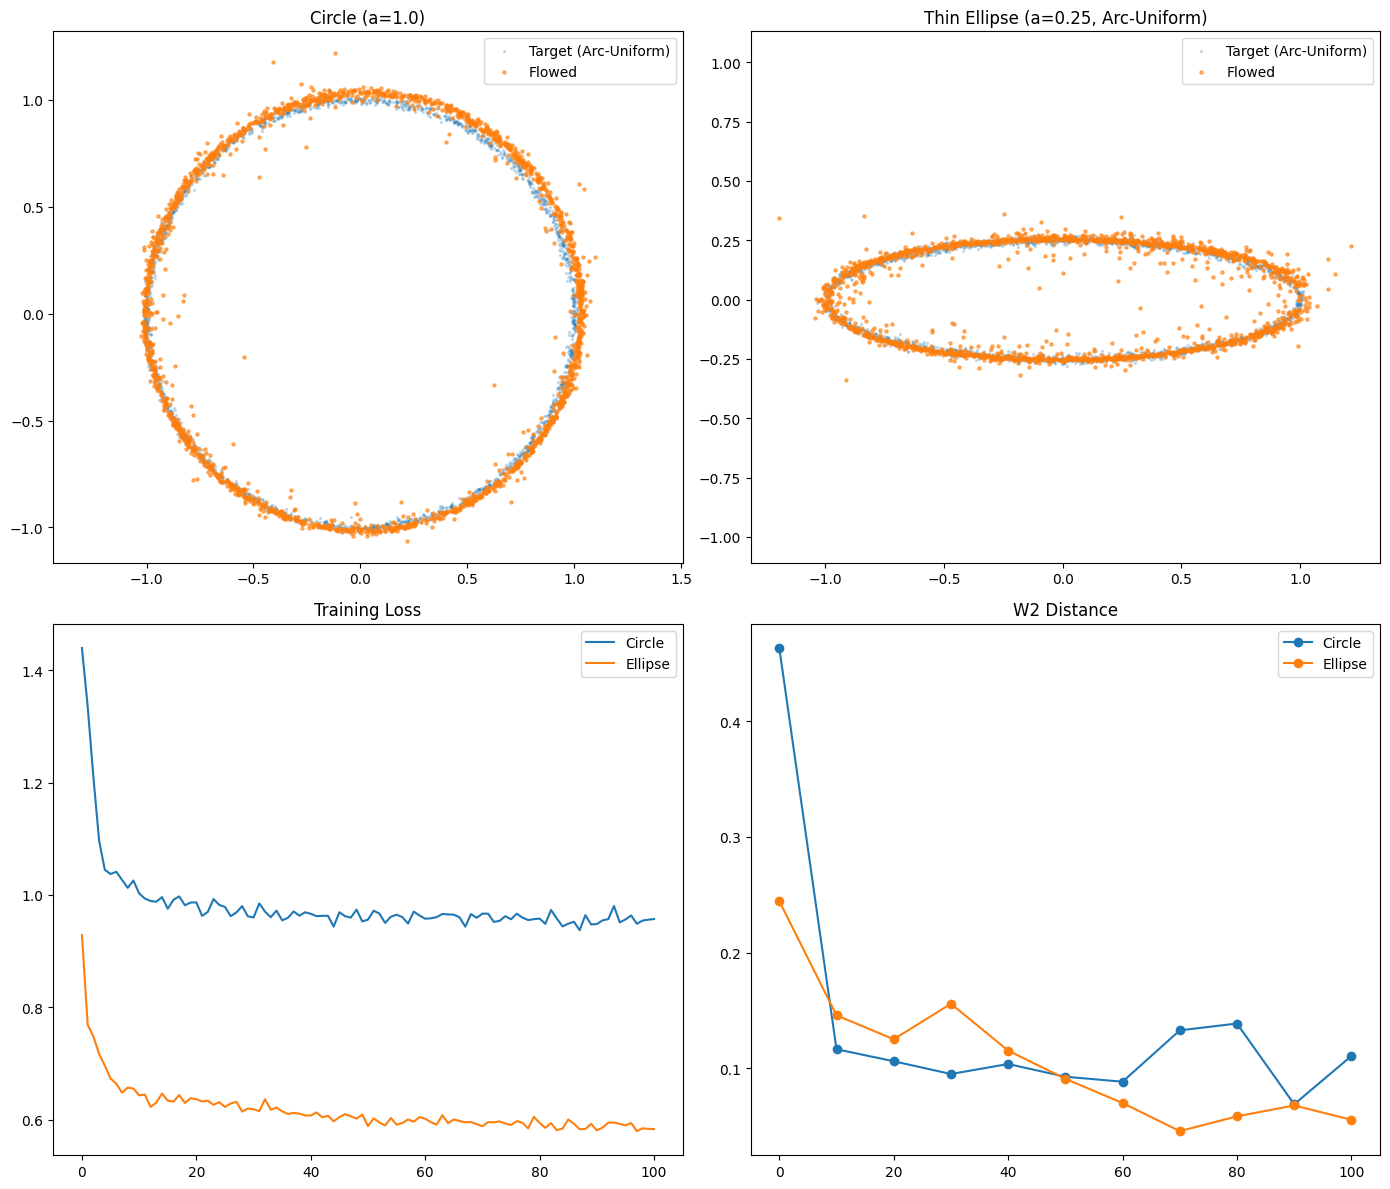

In [19]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from scipy.interpolate import interp1d
import ot

# --- 1. Dataset: Arc-Length Uniform Ellipse ---
class EllipseDataset(Dataset):
    def __init__(self, a, n_samples=20000, noise=0.01):
        """
        Generates points uniform along the length of the curve.
        x = cos(theta), y = a * sin(theta)
        """
        # 1. Generate a fine grid of thetas to calculate arc length
        n_fine = 10000
        theta_fine = np.linspace(0, 2 * np.pi, n_fine)
        x_fine = np.cos(theta_fine)
        y_fine = a * np.sin(theta_fine)
        
        # 2. Compute cumulative arc length
        # ds = sqrt(dx^2 + dy^2)
        dx = np.diff(x_fine)
        dy = np.diff(y_fine)
        ds = np.sqrt(dx**2 + dy**2)
        cumulative_length = np.cumsum(ds)
        cumulative_length = np.insert(cumulative_length, 0, 0.0)
        total_length = cumulative_length[-1]
        
        # 3. Create an interpolation function: length -> theta
        # This maps a linear distance [0, total_length] back to the required angle
        length_to_theta = interp1d(cumulative_length, theta_fine, kind='linear')
        
        # 4. Sample uniformly in length space
        sampled_lengths = np.random.uniform(0, total_length, n_samples)
        theta_uniform = torch.from_numpy(length_to_theta(sampled_lengths)).float()
        
        # 5. Generate final points
        x = torch.cos(theta_uniform)
        y = a * torch.sin(theta_uniform)
        
        self.data = torch.stack([x, y], dim=1) 
        self.data += torch.randn_like(self.data) * noise

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

# --- 2. Architecture (Transformer Vector Field) ---
class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        inv_freq = 1.0 / (10000 ** (torch.arange(0, dim, 2).float() / dim))
        self.register_buffer("inv_freq", inv_freq)

    def forward(self, t):
        exponents = t[:, None] * self.inv_freq[None, :]
        return torch.cat([exponents.sin(), exponents.cos()], dim=-1)

class TransformerVF(nn.Module):
    def __init__(self, input_dim=2, model_dim=32, num_heads=4):
        super().__init__()
        self.time_mlp = nn.Sequential(
            TimeEmbedding(model_dim),
            nn.Linear(model_dim, model_dim),
            nn.SiLU(),
            nn.Linear(model_dim, model_dim)
        )
        self.input_proj = nn.Linear(input_dim, model_dim)
        layer = nn.TransformerEncoderLayer(
            d_model=model_dim, nhead=num_heads, 
            dim_feedforward=model_dim*2, activation="gelu", batch_first=True
        )
        self.transformer = nn.TransformerEncoder(layer, num_layers=3)
        self.output_proj = nn.Linear(model_dim, input_dim)

    def forward(self, t, x):
        t_emb = self.time_mlp(t).unsqueeze(1) 
        x_emb = self.input_proj(x).unsqueeze(1) 
        h = self.transformer(torch.cat([t_emb, x_emb], dim=1))
        return self.output_proj(h[:, 1, :])

# --- 3. Utilities ---
@torch.no_grad()
def calculate_w2(model, true_data_sample, device, n_samples=1000):
    model.eval()
    x = torch.randn(n_samples, 2).to(device)
    steps = 50
    dt = 1.0 / steps
    for i in range(steps):
        t = torch.ones(n_samples, device=device) * (i / steps)
        x = x + model(t, x) * dt
    
    M = ot.dist(x.cpu().numpy(), 
                true_data_sample[torch.randperm(len(true_data_sample))[:n_samples]].cpu().numpy(), 
                metric='sqeuclidean')
    return np.sqrt(ot.emd2([], [], M))

def train_model(a, epochs=100, device='cpu'):
    dataset = EllipseDataset(a=a)
    dataloader = DataLoader(dataset, batch_size=512, shuffle=True)
    model = TransformerVF().to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)
    
    loss_hist, w2_hist, epochs_eval = [], [], []

    for epoch in range(epochs + 1):
        model.train()
        total_loss = 0
        for x1 in dataloader:
            x1, x0 = x1.to(device), torch.randn_like(x1).to(device)
            t = torch.rand(x1.shape[0], device=device)
            xt = (1 - t[:, None]) * x0 + t[:, None] * x1
            loss = nn.functional.mse_loss(model(t, xt), x1 - x0)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item()
        
        loss_hist.append(total_loss / len(dataloader))
        if epoch % 10 == 0:
            w2 = calculate_w2(model, dataset.data, device)
            w2_hist.append(w2); epochs_eval.append(epoch)
            print(f"[a={a}] Epoch {epoch} | Loss: {loss_hist[-1]:.4f} | W2: {w2:.4f}")
            
    return model, dataset, loss_hist, w2_hist, epochs_eval

# --- 4. Run & Plot ---
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu")
print("Using device:", device)
print("Training Circle (a=1.0)...")
m1, d1, l1, w1, e1 = train_model(a=1.0, device=device)
print("\nTraining Arc-Length Uniform Ellipse (a=0.25)...")
m2, d2, l2, w2, e2 = train_model(a=0.25, device=device)

fig, axs = plt.subplots(2, 2, figsize=(14, 12))

def plot_samples(model, dataset, ax, title):
    model.eval()
    with torch.no_grad():
        x = torch.randn(2000, 2).to(device)
        for i in range(50): x = x + model(torch.ones(2000, device=device)*(i/50), x) * (1/50)
    samples = x.cpu().numpy()
    ax.scatter(dataset.data[:2000, 0], dataset.data[:2000, 1], s=2, alpha=0.2, label='Target (Arc-Uniform)')
    ax.scatter(samples[:, 0], samples[:, 1], s=5, alpha=0.6, label='Flowed')
    ax.set_title(title); ax.legend(); ax.axis('equal')

plot_samples(m1, d1, axs[0, 0], "Circle (a=1.0)")
plot_samples(m2, d2, axs[0, 1], "Thin Ellipse (a=0.25, Arc-Uniform)")

axs[1, 0].plot(l1, label='Circle'); axs[1, 0].plot(l2, label='Ellipse'); axs[1, 0].set_title("Training Loss"); axs[1, 0].legend()
axs[1, 1].plot(e1, w1, marker='o', label='Circle'); axs[1, 1].plot(e2, w2, marker='o', label='Ellipse'); axs[1, 1].set_title("W2 Distance"); axs[1, 1].legend()

plt.tight_layout()
plt.show()

## Wiggly Circle

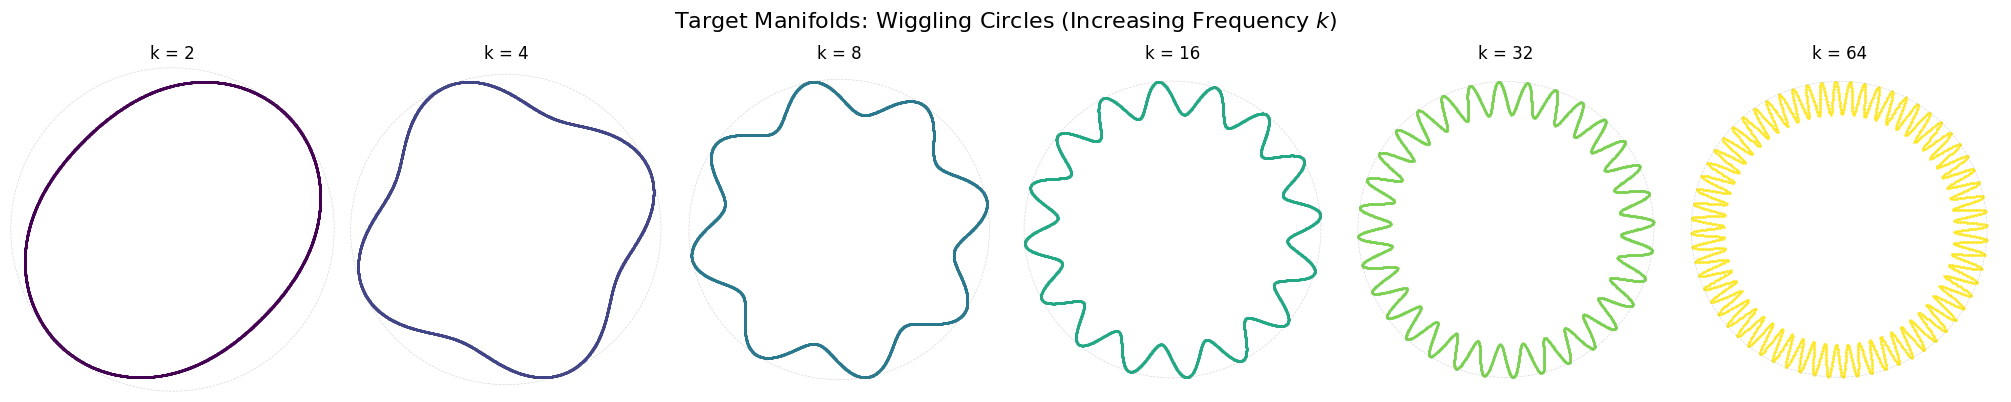

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# --- 1. Data Generation Function ---
def get_wiggling_curve(k, R=1.0, A=0.125, n_samples=3000):
    """Generates arc-length uniform samples for a wiggling circle."""
    n_fine = 10000
    theta_fine = np.linspace(0, 2 * np.pi, n_fine)
    r = R + A * np.sin(k * theta_fine)
    x_fine = r * np.cos(theta_fine)
    y_fine = r * np.sin(theta_fine)
    
    # Cumulative arc length for uniform sampling
    ds = np.sqrt(np.diff(x_fine)**2 + np.diff(y_fine)**2)
    cumulative_length = np.insert(np.cumsum(ds), 0, 0.0)
    
    length_to_theta = interp1d(cumulative_length, theta_fine, kind='linear')
    sampled_lengths = np.linspace(0, cumulative_length[-1], n_samples)
    theta_uniform = length_to_theta(sampled_lengths)
    
    r_u = R + A * np.sin(k * theta_uniform)
    return r_u * np.cos(theta_uniform), r_u * np.sin(theta_uniform)

# --- 2. Plotting Row ---
b_values = [1, 2, 3, 4, 5, 6]
k_values = [2**b for b in b_values]
colors = plt.cm.viridis(np.linspace(0, 1, len(k_values)))

fig, axs = plt.subplots(1, len(k_values), figsize=(20, 4), constrained_layout=True)
fig.suptitle("Target Manifolds: Wiggling Circles (Increasing Frequency $k$)", fontsize=16, y=1.05)

for i, k in enumerate(k_values):
    x, y = get_wiggling_curve(k)
    
    # Plot the curve
    axs[i].scatter(x, y, s=1, color=colors[i], alpha=0.8)
    
    # Formatting
    axs[i].set_title(f"k = {k}")
    axs[i].set_aspect('equal')
    axs[i].axis('off')
    
    # Optional: Add a subtle boundary for scale
    circle = plt.Circle((0, 0), 1.125, color='gray', fill=False, lw=0.5, ls='--', alpha=0.3)
    axs[i].add_patch(circle)

plt.show()

Using device: mps
Starting experiment for k = [2, 4, 8, 16, 32, 64]
Training k=2...
Training k=4...
Training k=8...
Training k=16...
Training k=32...
Training k=64...


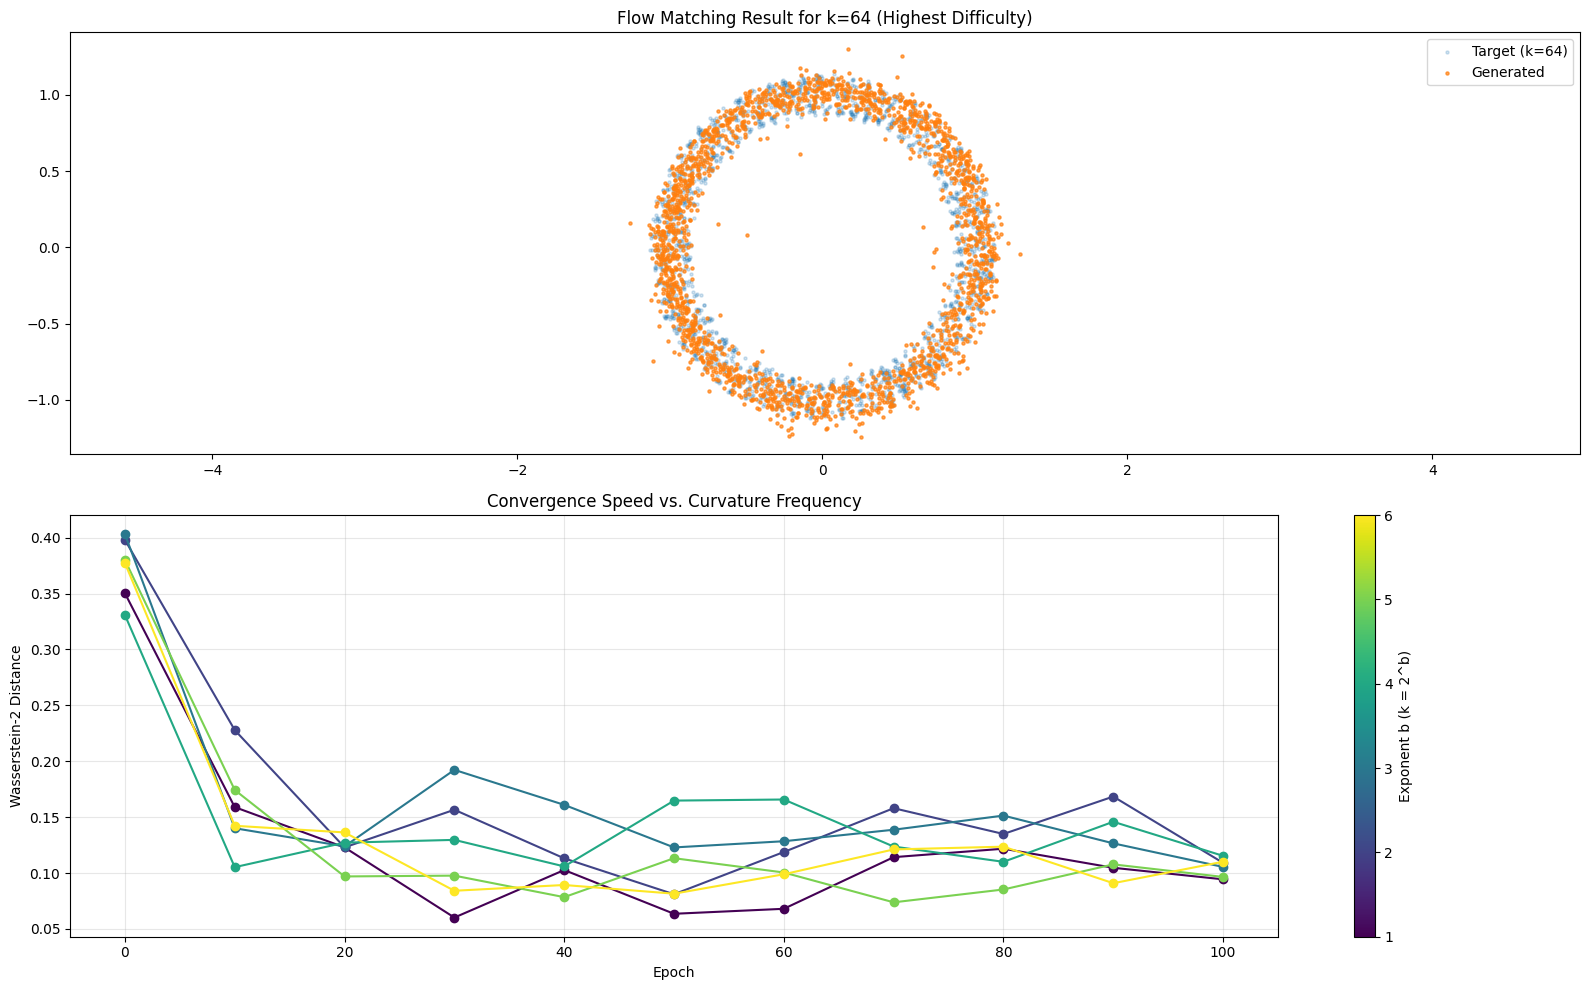

In [20]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from scipy.interpolate import interp1d
import ot
import matplotlib.cm as cm

# --- 1. Setup Device ---
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print("Using device:", device)

# --- 2. Arc-Length Uniform Wiggling Dataset ---
class WigglingDataset(Dataset):
    def __init__(self, k, R=1.0, A=0.125, n_samples=20000, noise=0.01):
        # High-res grid for numerical integration (k can be up to 64)
        n_fine = 20000 
        theta_fine = np.linspace(0, 2 * np.pi, n_fine)
        
        # r(theta) = R + A * sin(k * theta)
        r = R + A * np.sin(k * theta_fine)
        x_fine = r * np.cos(theta_fine)
        y_fine = r * np.sin(theta_fine)
        
        # Compute cumulative arc length
        dx = np.diff(x_fine)
        dy = np.diff(y_fine)
        ds = np.sqrt(dx**2 + dy**2)
        cumulative_length = np.cumsum(ds)
        cumulative_length = np.insert(cumulative_length, 0, 0.0)
        
        # Interpolator: length -> theta
        length_to_theta = interp1d(cumulative_length, theta_fine, kind='linear')
        
        # Sample uniformly along the length
        total_length = cumulative_length[-1]
        sampled_lengths = np.random.uniform(0, total_length, n_samples)
        theta_uniform = torch.from_numpy(length_to_theta(sampled_lengths)).float()
        
        # Final Coordinates
        r_u = R + A * torch.sin(k * theta_uniform)
        self.data = torch.stack([r_u * torch.cos(theta_uniform), 
                                 r_u * torch.sin(theta_uniform)], dim=1)
        self.data += torch.randn_like(self.data) * noise

    def __len__(self): return len(self.data)
    def __getitem__(self, idx): return self.data[idx]

# --- 3. Model Architecture ---
class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        inv_freq = 1.0 / (10000 ** (torch.arange(0, dim, 2).float() / dim))
        self.register_buffer("inv_freq", inv_freq)

    def forward(self, t):
        exponents = t[:, None] * self.inv_freq[None, :]
        return torch.cat([exponents.sin(), exponents.cos()], dim=-1)

class TransformerVF(nn.Module):
    def __init__(self, input_dim=2, model_dim=64, num_heads=4):
        super().__init__()
        self.time_mlp = nn.Sequential(
            TimeEmbedding(model_dim), nn.Linear(model_dim, model_dim),
            nn.SiLU(), nn.Linear(model_dim, model_dim)
        )
        self.input_proj = nn.Linear(input_dim, model_dim)
        layer = nn.TransformerEncoderLayer(d_model=model_dim, nhead=num_heads, 
                                           dim_feedforward=model_dim*2, activation="gelu", batch_first=True)
        self.transformer = nn.TransformerEncoder(layer, num_layers=3)
        self.output_proj = nn.Linear(model_dim, input_dim)

    def forward(self, t, x):
        t_emb = self.time_mlp(t).unsqueeze(1)
        x_emb = self.input_proj(x).unsqueeze(1)
        h = self.transformer(torch.cat([t_emb, x_emb], dim=1))
        return self.output_proj(h[:, 1, :])

# --- 4. Training and Metrics ---
@torch.no_grad()
def calculate_w2(model, true_data, n_samples=1000):
    model.eval()
    x = torch.randn(n_samples, 2).to(device)
    steps = 50
    dt = 1.0 / steps
    for i in range(steps):
        t = torch.ones(n_samples, device=device) * (i / steps)
        x = x + model(t, x) * dt
    
    M = ot.dist(x.cpu().numpy(), 
                true_data[torch.randperm(len(true_data))[:n_samples]].cpu().numpy(), 
                metric='sqeuclidean')
    return np.sqrt(ot.emd2([], [], M))

def train_k(k_val, epochs=100):
    dataset = WigglingDataset(k=k_val)
    dataloader = DataLoader(dataset, batch_size=512, shuffle=True)
    model = TransformerVF().to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4)
    
    w2_history = []
    eval_epochs = []
    
    for epoch in range(epochs + 1):
        model.train()
        for x1 in dataloader:
            x1, x0 = x1.to(device), torch.randn_like(x1).to(device)
            t = torch.rand(x1.shape[0], device=device)
            xt = (1 - t[:, None]) * x0 + t[:, None] * x1
            loss = nn.functional.mse_loss(model(t, xt), x1 - x0)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
        
        if epoch % 10 == 0:
            w2 = calculate_w2(model, dataset.data)
            w2_history.append(w2)
            eval_epochs.append(epoch)
    
    return model, w2_history, eval_epochs, dataset.data

# --- 5. Run Experiment ---
b_values = [1, 2, 3, 4, 5, 6]
k_values = [2**b for b in b_values]
results = {}

print(f"Starting experiment for k = {k_values}")
for k in k_values:
    print(f"Training k={k}...")
    results[k] = train_k(k)

# --- 6. Visualization ---
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 3)

# Subplot 1: Samples for highest k (k=64)
ax_samp = fig.add_subplot(gs[0, :])
model_64, _, _, true_64 = results[64]
model_64.eval()
with torch.no_grad():
    x_gen = torch.randn(2000, 2).to(device)
    for i in range(100): x_gen += model_64(torch.ones(2000, device=device)*(i/100), x_gen) * (1/100)
x_gen = x_gen.cpu().numpy()
ax_samp.scatter(true_64[:2000, 0], true_64[:2000, 1], s=5, alpha=0.2, label="Target (k=64)")
ax_samp.scatter(x_gen[:, 0], x_gen[:, 1], s=5, alpha=0.7, label="Generated")
ax_samp.set_title("Flow Matching Result for k=64 (Highest Difficulty)")
ax_samp.axis('equal'); ax_samp.legend()

# Subplot 2: W2 Comparison with Colorbar
ax_w2 = fig.add_subplot(gs[1, :])
norm = plt.Normalize(min(b_values), max(b_values))
colormap = cm.viridis

for b, k in zip(b_values, k_values):
    _, w2_h, e_h, _ = results[k]
    ax_w2.plot(e_h, w2_h, marker='o', color=colormap(norm(b)), label=f"k={k}")

ax_w2.set_xlabel("Epoch")
ax_w2.set_ylabel("Wasserstein-2 Distance")
ax_w2.set_title("Convergence Speed vs. Curvature Frequency")
ax_w2.grid(True, alpha=0.3)

# Add Colorbar
sm = cm.ScalarMappable(cmap=colormap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax_w2, orientation='vertical')
cbar.set_label('Exponent b (k = 2^b)')

plt.tight_layout()
plt.show()

### Live Wiggly Circle Training

# Flow Matching for High-Curvature Manifolds

This program implements a **Continuous Normalizing Flow (CNF)** via **Flow Matching** to learn a series of target distributions: "Wiggling Circles" with increasing geometric complexity.

## 1. Mathematical Objective
The goal is to learn a vector field $v_t(x)$ that generates a flow $\phi_t$ transporting probability mass from a source distribution $p_0$ (Standard Gaussian) to a target distribution $p_1$ (Wiggling Circle).

### The Target Manifold
The target shape is defined in polar coordinates by the radius function:
$$r(\theta) = R + A \sin(k\theta)$$
where:
* **$R=1.0$**: Base radius.
* **$A=0.125$**: Amplitude of the "wiggles."
* **$k = 2^b$**: Frequency of oscillations (curvatures increase exponentially with $b$).

### Arc-Length Uniform Sampling
To ensure the model learns the geometry rather than parameterization density, the data is re-parameterized to be uniform along the arc length $s$. Since the arc length of an ellipse/wiggle has no closed-form inverse, we use numerical integration:
1. Compute $ds = \sqrt{r^2 + (\frac{dr}{d\theta})^2} d\theta$.
2. Compute the cumulative length $S(\theta) = \int_0^\theta ds$.
3. Sample $s \sim \text{Uniform}(0, S_{total})$ and invert to find $\theta$.

## 2. Architecture & Improvements

### Fourier Features (Positional Encoding)
Neural networks suffer from **Spectral Bias**, meaning they struggle to learn high-frequency functions. To map the $k=64$ peaks effectively, we project the 2D input $x$ into a high-dimensional space using random Fourier features:
$$\gamma(x) = [\cos(2\pi Bx), \sin(2\pi Bx)]^T$$
This allows the Transformer to resolve fine spatial details that are otherwise "blurry" to a standard MLP.

### Skewed Time Sampling
The most difficult part of the flow occurs near $t=1$, where the "Gaussian cloud" must condense into sharp jagged lines. We use a **Power-Law Sampler** for training:
$$t = 1 - (1 - u)^2, \quad u \sim \text{Uniform}(0, 1)$$
This skews the training distribution so that the model sees more examples of the "last mile" of the transformation, improving the resolution of the final manifold.

### Transformer Vector Field
The model uses a Time-Dependent Transformer. It treats the time embedding and the spatial coordinates as tokens in a sequence:
* **Time Embedding**: Sinusoidal encoding of the scalar $t$.
* **Vector Field**: The model predicts the velocity $v_t = x_1 - x_0$, which defines the straight-line path between noise and data.

## 3. Visualization Dashboard
The training loop provides a live dashboard consisting of:
1.  **Sampling Plots**: A row showing the generated points (colored) versus the true target (gray).
2.  **Convergence Analysis**: A log-scale plot of the **Wasserstein-2 (W2) Distance**.
    * *Lower $k$* (e.g., $k=2$) converges rapidly.
    * *Higher $k$* (e.g., $k=64$) demonstrates the difficulty of resolving high-curvature features even with Fourier Features.

## 4. Sampling (Inference)
During evaluation, the model performs **ODE Integration** (Euler Method):
$$x_{t+\Delta t} = x_t + v_t(x_t) \Delta t$$
Increasing the number of integration steps (e.g., from 40 to 100) is necessary for high $k$ to prevent the particles from "overshooting" the tight turns in the vector field.

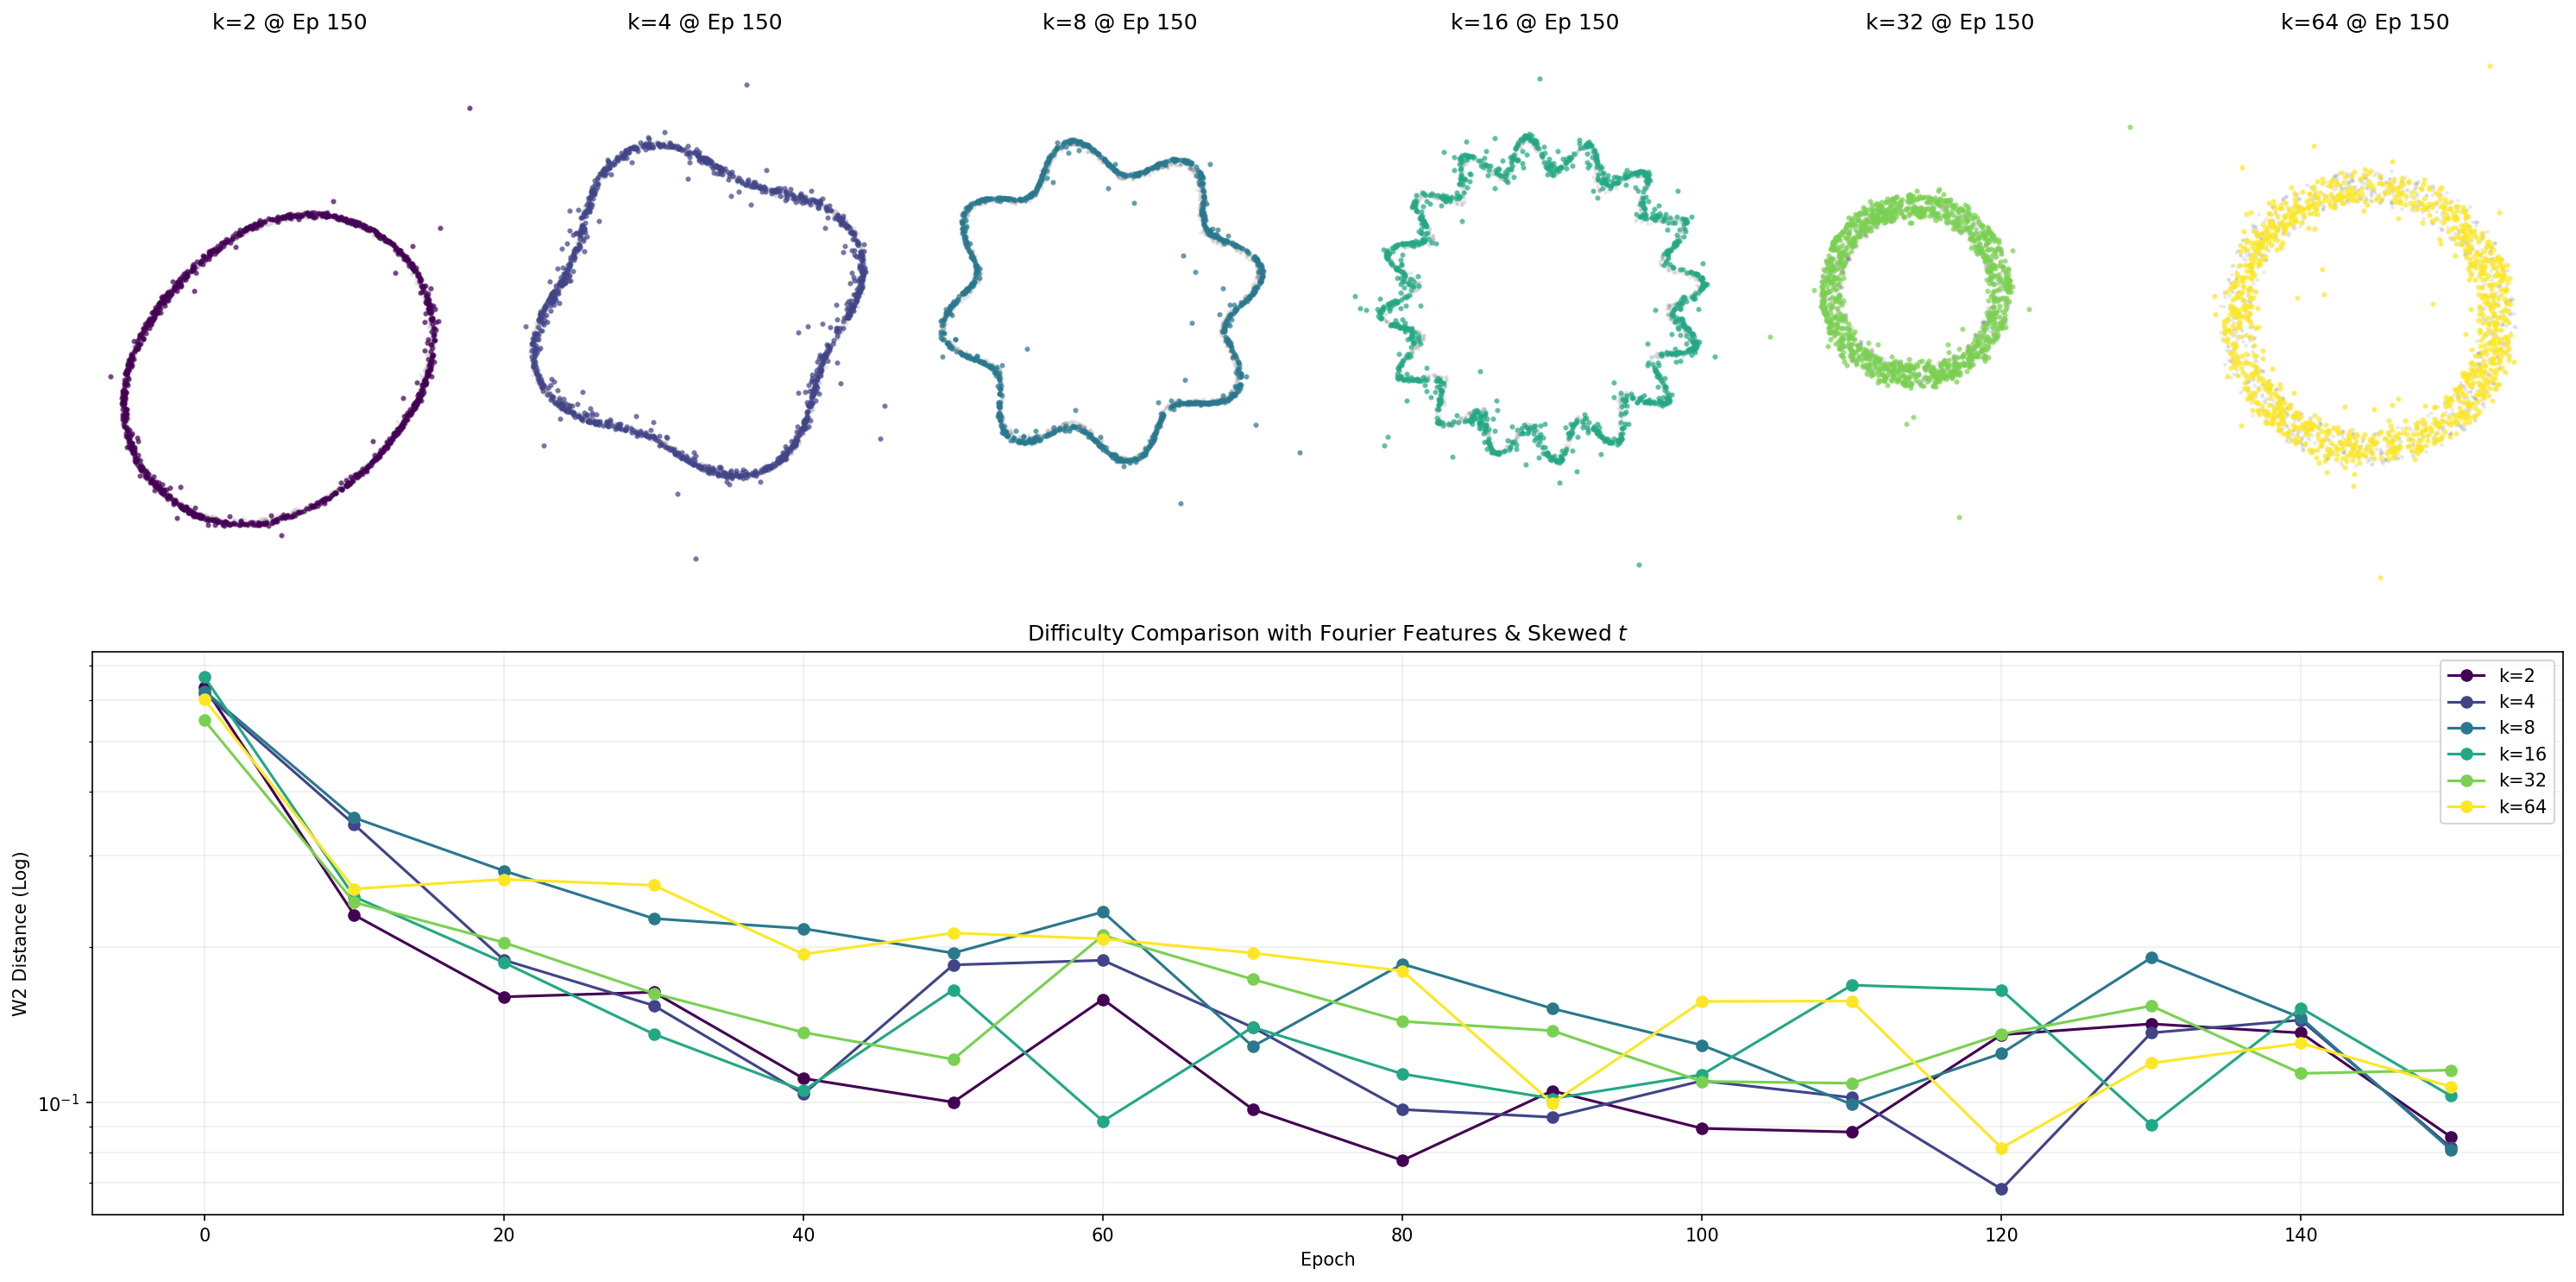

Training Complete.


In [14]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from scipy.interpolate import interp1d
import ot
from IPython.display import display, clear_output

# --- 1. Setup Device ---
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

# --- 2. Fourier Features (The High-Frequency Lens) ---
class FourierFeatures(nn.Module):
    def __init__(self, in_features, out_features, sigma=1.0):
        super().__init__()
        # Use nn.Parameter instead of register_buffer
        # This makes B trainable
        self.B = nn.Parameter(torch.randn(in_features, out_features // 2) * sigma)

    def forward(self, x):
        # Maps (batch, 2) -> (batch, out_features)
        proj = torch.matmul(x, self.B) * 2 * np.pi
        return torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)

# --- 3. Dataset and Model ---
class WigglingDataset(Dataset):
    def __init__(self, k, R=1.0, A=0.125, n_samples=20000, noise=0.01):
        n_fine = 20000 
        theta_fine = np.linspace(0, 2 * np.pi, n_fine)
        r = R + A * np.sin(k * theta_fine)
        x_fine, y_fine = r * np.cos(theta_fine), r * np.sin(theta_fine)
        ds = np.sqrt(np.diff(x_fine)**2 + np.diff(y_fine)**2)
        cumulative_length = np.insert(np.cumsum(ds), 0, 0.0)
        length_to_theta = interp1d(cumulative_length, theta_fine, kind='linear')
        sampled_lengths = np.random.uniform(0, cumulative_length[-1], n_samples)
        theta_u = torch.from_numpy(length_to_theta(sampled_lengths)).float()
        r_u = R + A * torch.sin(k * theta_u)
        self.data = torch.stack([r_u * torch.cos(theta_u), r_u * torch.sin(theta_u)], dim=1) + torch.randn(n_samples, 2) * noise
    def __len__(self): return len(self.data)
    def __getitem__(self, idx): return self.data[idx]

class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        inv_freq = 1.0 / (10000 ** (torch.arange(0, dim, 2).float() / dim))
        self.register_buffer("inv_freq", inv_freq)
    def forward(self, t):
        exponents = t[:, None] * self.inv_freq[None, :]
        return torch.cat([exponents.sin(), exponents.cos()], dim=-1)

class TransformerVF(nn.Module):
    def __init__(self, input_dim=2, model_dim=64, num_heads=4):
        super().__init__()
        self.time_mlp = nn.Sequential(TimeEmbedding(model_dim), nn.Linear(model_dim, model_dim), nn.SiLU(), nn.Linear(model_dim, model_dim))
        
        # KEY UPDATE: Replace Linear proj with Fourier Features
        self.input_proj = FourierFeatures(input_dim, model_dim, sigma=1.0) 
        
        layer = nn.TransformerEncoderLayer(d_model=model_dim, nhead=num_heads, dim_feedforward=model_dim*2, activation="gelu", batch_first=True)
        self.transformer = nn.TransformerEncoder(layer, num_layers=3)
        self.output_proj = nn.Linear(model_dim, input_dim)
        
    def forward(self, t, x):
        h = self.transformer(torch.cat([self.time_mlp(t).unsqueeze(1), self.input_proj(x).unsqueeze(1)], dim=1))
        return self.output_proj(h[:, 1, :])

# --- 4. Parallel Training Setup ---
b_values = [1, 2, 3, 4, 5, 6]
k_values = [2**b for b in b_values]
models = {k: TransformerVF().to(device) for k in k_values}
optimizers = {k: torch.optim.AdamW(models[k].parameters(), lr=5e-4) for k in k_values}
datasets = {k: WigglingDataset(k) for k in k_values}
dataloaders = {k: DataLoader(datasets[k], batch_size=512, shuffle=True) for k in k_values}

w2_histories = {k: [] for k in k_values}
eval_epochs = []
epochs = 150 # Slightly more epochs to see the effect of the Fourier features
colors = plt.cm.viridis(np.linspace(0, 1, len(k_values)))

# --- 5. Live Dashboard Loop ---
for epoch in range(epochs + 1):
    for k in k_values:
        models[k].train()
        for x1 in dataloaders[k]:
            x1, x0 = x1.to(device), torch.randn_like(x1).to(device)
            
            # KEY UPDATE: Skew t towards 1.0 using Power Law 
            # 1 - (1-u)^2 puts ~75% of samples in the t > 0.5 range
            u = torch.rand(x1.shape[0], device=device)
            t = 1 - (1 - u)**2 
            
            xt = (1 - t[:, None]) * x0 + t[:, None] * x1
            loss = nn.functional.mse_loss(models[k](t, xt), x1 - x0)
            optimizers[k].zero_grad(); loss.backward(); optimizers[k].step()

    if epoch % 10 == 0:
        eval_epochs.append(epoch)
        clear_output(wait=True)
        fig = plt.figure(figsize=(20, 10), dpi=150)
        gs = fig.add_gridspec(2, 6)

        for i, k in enumerate(k_values):
            models[k].eval()
            with torch.no_grad():
                # KEY UPDATE: Better Sampling (Higher steps for resolution)
                x_gen = torch.randn(1200, 2).to(device)
                sampling_steps = 100 
                dt = 1.0 / sampling_steps
                for step in range(sampling_steps):
                    t_val = torch.ones(1200, device=device) * (step/sampling_steps)
                    x_gen += models[k](t_val, x_gen) * dt
                
                gen_np = x_gen.cpu().numpy()
                target_np = datasets[k].data[torch.randperm(20000)[:1200]].cpu().numpy()
                M = ot.dist(gen_np, target_np, metric='sqeuclidean')
                w2_histories[k].append(np.sqrt(ot.emd2([], [], M)))

                ax = fig.add_subplot(gs[0, i])
                ax.scatter(target_np[:, 0], target_np[:, 1], s=2, alpha=0.1, color='gray')
                ax.scatter(gen_np[:, 0], gen_np[:, 1], s=4, alpha=0.6, color=colors[i])
                ax.set_title(f"k={k} @ Ep {epoch}")
                ax.axis('equal'); ax.axis('off')

        ax_w2 = fig.add_subplot(gs[1, :])
        for i, k in enumerate(k_values):
            ax_w2.plot(eval_epochs, w2_histories[k], marker='o', color=colors[i], label=f"k={k}")
        
        ax_w2.set_yscale('log'); ax_w2.set_xlabel("Epoch"); ax_w2.set_ylabel("W2 Distance (Log)")
        ax_w2.legend(loc='upper right'); ax_w2.set_title("Difficulty Comparison with Fourier Features & Skewed $t$")
        ax_w2.grid(True, which="both", alpha=0.2)
        plt.tight_layout(); plt.show()

print("Training Complete.")

#### MLP instead of Transformer

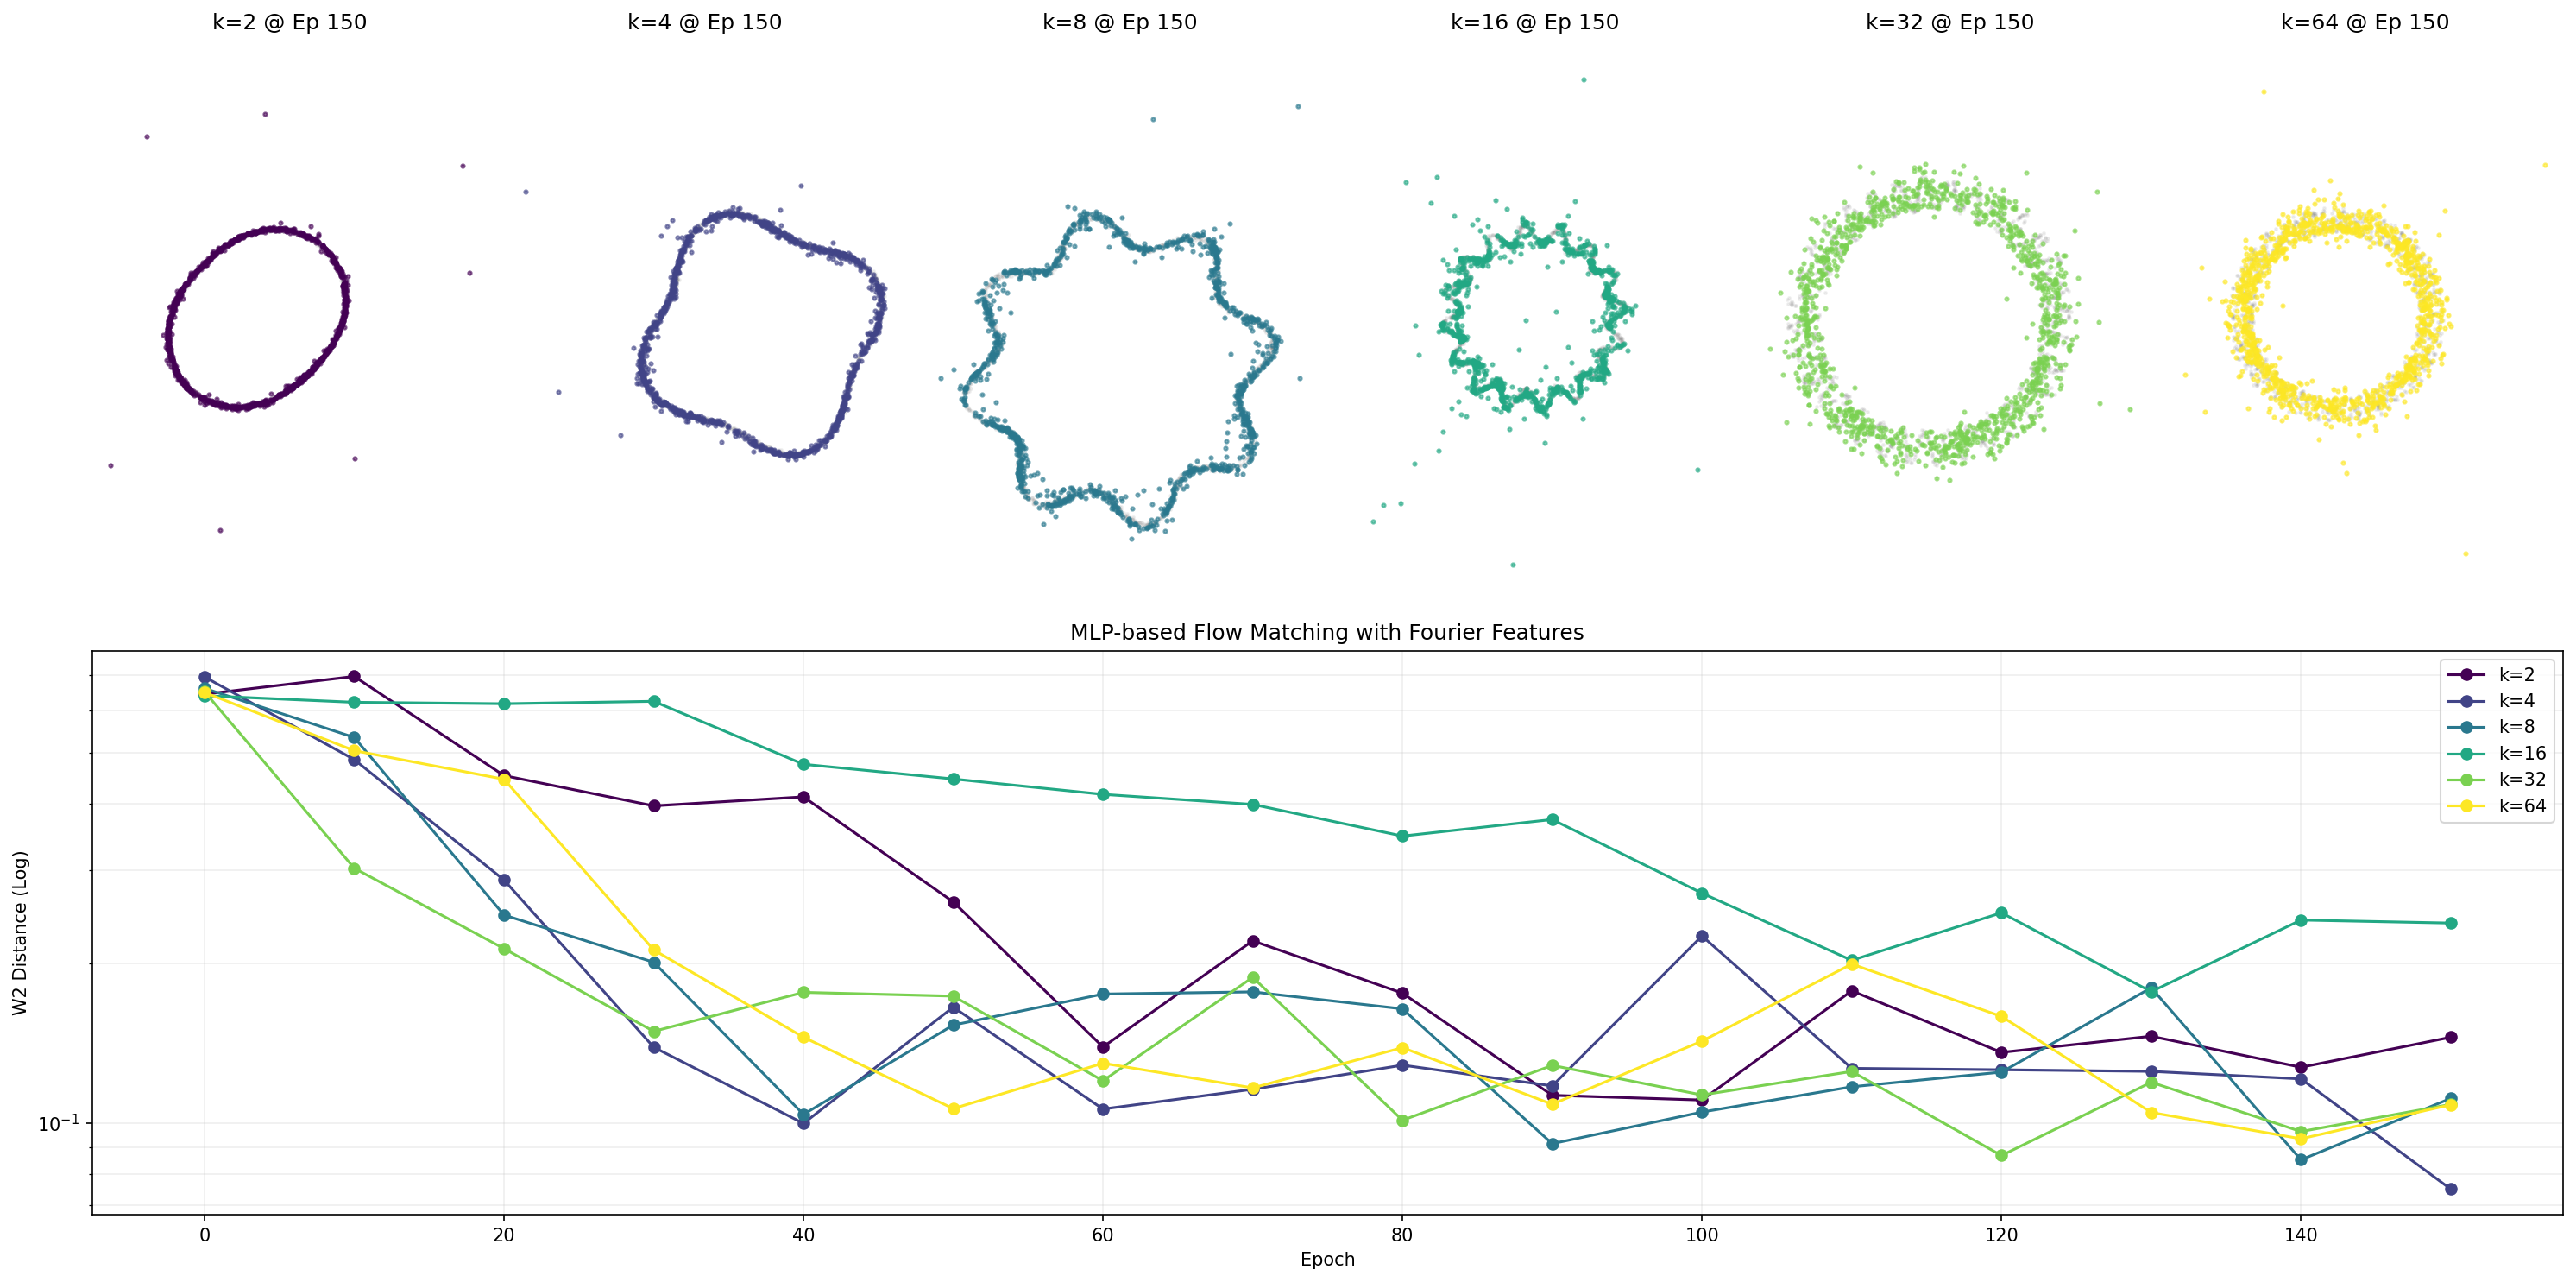

Training Complete.


In [16]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from scipy.interpolate import interp1d
import ot
from IPython.display import display, clear_output

# --- 1. Setup Device ---
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

# --- 2. Components ---
class FourierFeatures(nn.Module):
    def __init__(self, in_features, out_features, sigma=1.0):
        super().__init__()
        self.B = nn.Parameter(torch.randn(in_features, out_features // 2) * sigma)

    def forward(self, x):
        proj = torch.matmul(x, self.B) * 2 * np.pi
        return torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)

class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        inv_freq = 1.0 / (10000 ** (torch.arange(0, dim, 2).float() / dim))
        self.register_buffer("inv_freq", inv_freq)
    def forward(self, t):
        exponents = t[:, None] * self.inv_freq[None, :]
        return torch.cat([exponents.sin(), exponents.cos()], dim=-1)

# --- 3. MLP Vector Field ---
class MLP_VF(nn.Module):
    def __init__(self, input_dim=2, model_dim=64):
        super().__init__()
        self.time_embed = nn.Sequential(
            TimeEmbedding(model_dim),
            nn.Linear(model_dim, model_dim),
            nn.SiLU()
        )
        self.input_proj = FourierFeatures(input_dim, model_dim, sigma=1.0)
        
        # A simple ResNet-style MLP block
        self.net = nn.Sequential(
            nn.Linear(model_dim * 2, model_dim),
            nn.SiLU(),
            nn.Linear(model_dim, model_dim),
            nn.SiLU(),
            nn.Linear(model_dim, model_dim),
            nn.SiLU(),
            nn.Linear(model_dim, input_dim)
        )

    def forward(self, t, x):
        t_emb = self.time_embed(t)
        x_emb = self.input_proj(x)
        # Concatenate time and space information
        h = torch.cat([t_emb, x_emb], dim=-1)
        return self.net(h)

# --- 4. Dataset ---
class WigglingDataset(Dataset):
    def __init__(self, k, R=1.0, A=0.125, n_samples=20000, noise=0.01):
        n_fine = 20000 
        theta_fine = np.linspace(0, 2 * np.pi, n_fine)
        r = R + A * np.sin(k * theta_fine)
        x_fine, y_fine = r * np.cos(theta_fine), r * np.sin(theta_fine)
        ds = np.sqrt(np.diff(x_fine)**2 + np.diff(y_fine)**2)
        cumulative_length = np.insert(np.cumsum(ds), 0, 0.0)
        length_to_theta = interp1d(cumulative_length, theta_fine, kind='linear')
        sampled_lengths = np.random.uniform(0, cumulative_length[-1], n_samples)
        theta_u = torch.from_numpy(length_to_theta(sampled_lengths)).float()
        r_u = R + A * torch.sin(k * theta_u)
        self.data = torch.stack([r_u * torch.cos(theta_u), r_u * torch.sin(theta_u)], dim=1) + torch.randn(n_samples, 2) * noise
    def __len__(self): return len(self.data)
    def __getitem__(self, idx): return self.data[idx]

# --- 5. Parallel Training Setup ---
b_values = [1, 2, 3, 4, 5, 6]
k_values = [2**b for b in b_values]
models = {k: MLP_VF(model_dim=64).to(device) for k in k_values}
optimizers = {k: torch.optim.AdamW(models[k].parameters(), lr=5e-4) for k in k_values}
datasets = {k: WigglingDataset(k) for k in k_values}
dataloaders = {k: DataLoader(datasets[k], batch_size=512, shuffle=True) for k in k_values}

w2_histories = {k: [] for k in k_values}
eval_epochs = []
epochs = 150
colors = plt.cm.viridis(np.linspace(0, 1, len(k_values)))

# --- 6. Training Loop ---
for epoch in range(epochs + 1):
    for k in k_values:
        models[k].train()
        for x1 in dataloaders[k]:
            x1, x0 = x1.to(device), torch.randn_like(x1).to(device)
            u = torch.rand(x1.shape[0], device=device)
            t = 1 - (1 - u)**2 # Skewed t
            xt = (1 - t[:, None]) * x0 + t[:, None] * x1
            loss = nn.functional.mse_loss(models[k](t, xt), x1 - x0)
            optimizers[k].zero_grad(); loss.backward(); optimizers[k].step()

    if epoch % 10 == 0:
        eval_epochs.append(epoch)
        clear_output(wait=True)
        fig = plt.figure(figsize=(20, 10), dpi=150)
        gs = fig.add_gridspec(2, 6)

        for i, k in enumerate(k_values):
            models[k].eval()
            with torch.no_grad():
                x_gen = torch.randn(1200, 2).to(device)
                sampling_steps = 100 
                dt = 1.0 / sampling_steps
                for step in range(sampling_steps):
                    t_val = torch.ones(1200, device=device) * (step/sampling_steps)
                    x_gen += models[k](t_val, x_gen) * dt
                
                gen_np = x_gen.cpu().numpy()
                target_np = datasets[k].data[torch.randperm(20000)[:1200]].cpu().numpy()
                M = ot.dist(gen_np, target_np, metric='sqeuclidean')
                w2_histories[k].append(np.sqrt(ot.emd2([], [], M)))

                ax = fig.add_subplot(gs[0, i])
                ax.scatter(target_np[:, 0], target_np[:, 1], s=2, alpha=0.1, color='gray')
                ax.scatter(gen_np[:, 0], gen_np[:, 1], s=4, alpha=0.6, color=colors[i])
                ax.set_title(f"k={k} @ Ep {epoch}")
                ax.axis('equal'); ax.axis('off')

        ax_w2 = fig.add_subplot(gs[1, :])
        for i, k in enumerate(k_values):
            ax_w2.plot(eval_epochs, w2_histories[k], marker='o', color=colors[i], label=f"k={k}")
        
        ax_w2.set_yscale('log'); ax_w2.set_xlabel("Epoch"); ax_w2.set_ylabel("W2 Distance (Log)")
        ax_w2.legend(loc='upper right'); ax_w2.set_title("MLP-based Flow Matching with Fourier Features")
        ax_w2.grid(True, which="both", alpha=0.2)
        plt.tight_layout(); plt.show()

print("Training Complete.")

### Flow Dynamics Visualisation

Calculating flow dynamics for k=2...
Calculating flow dynamics for k=4...
Calculating flow dynamics for k=8...
Calculating flow dynamics for k=16...
Calculating flow dynamics for k=32...
Calculating flow dynamics for k=64...


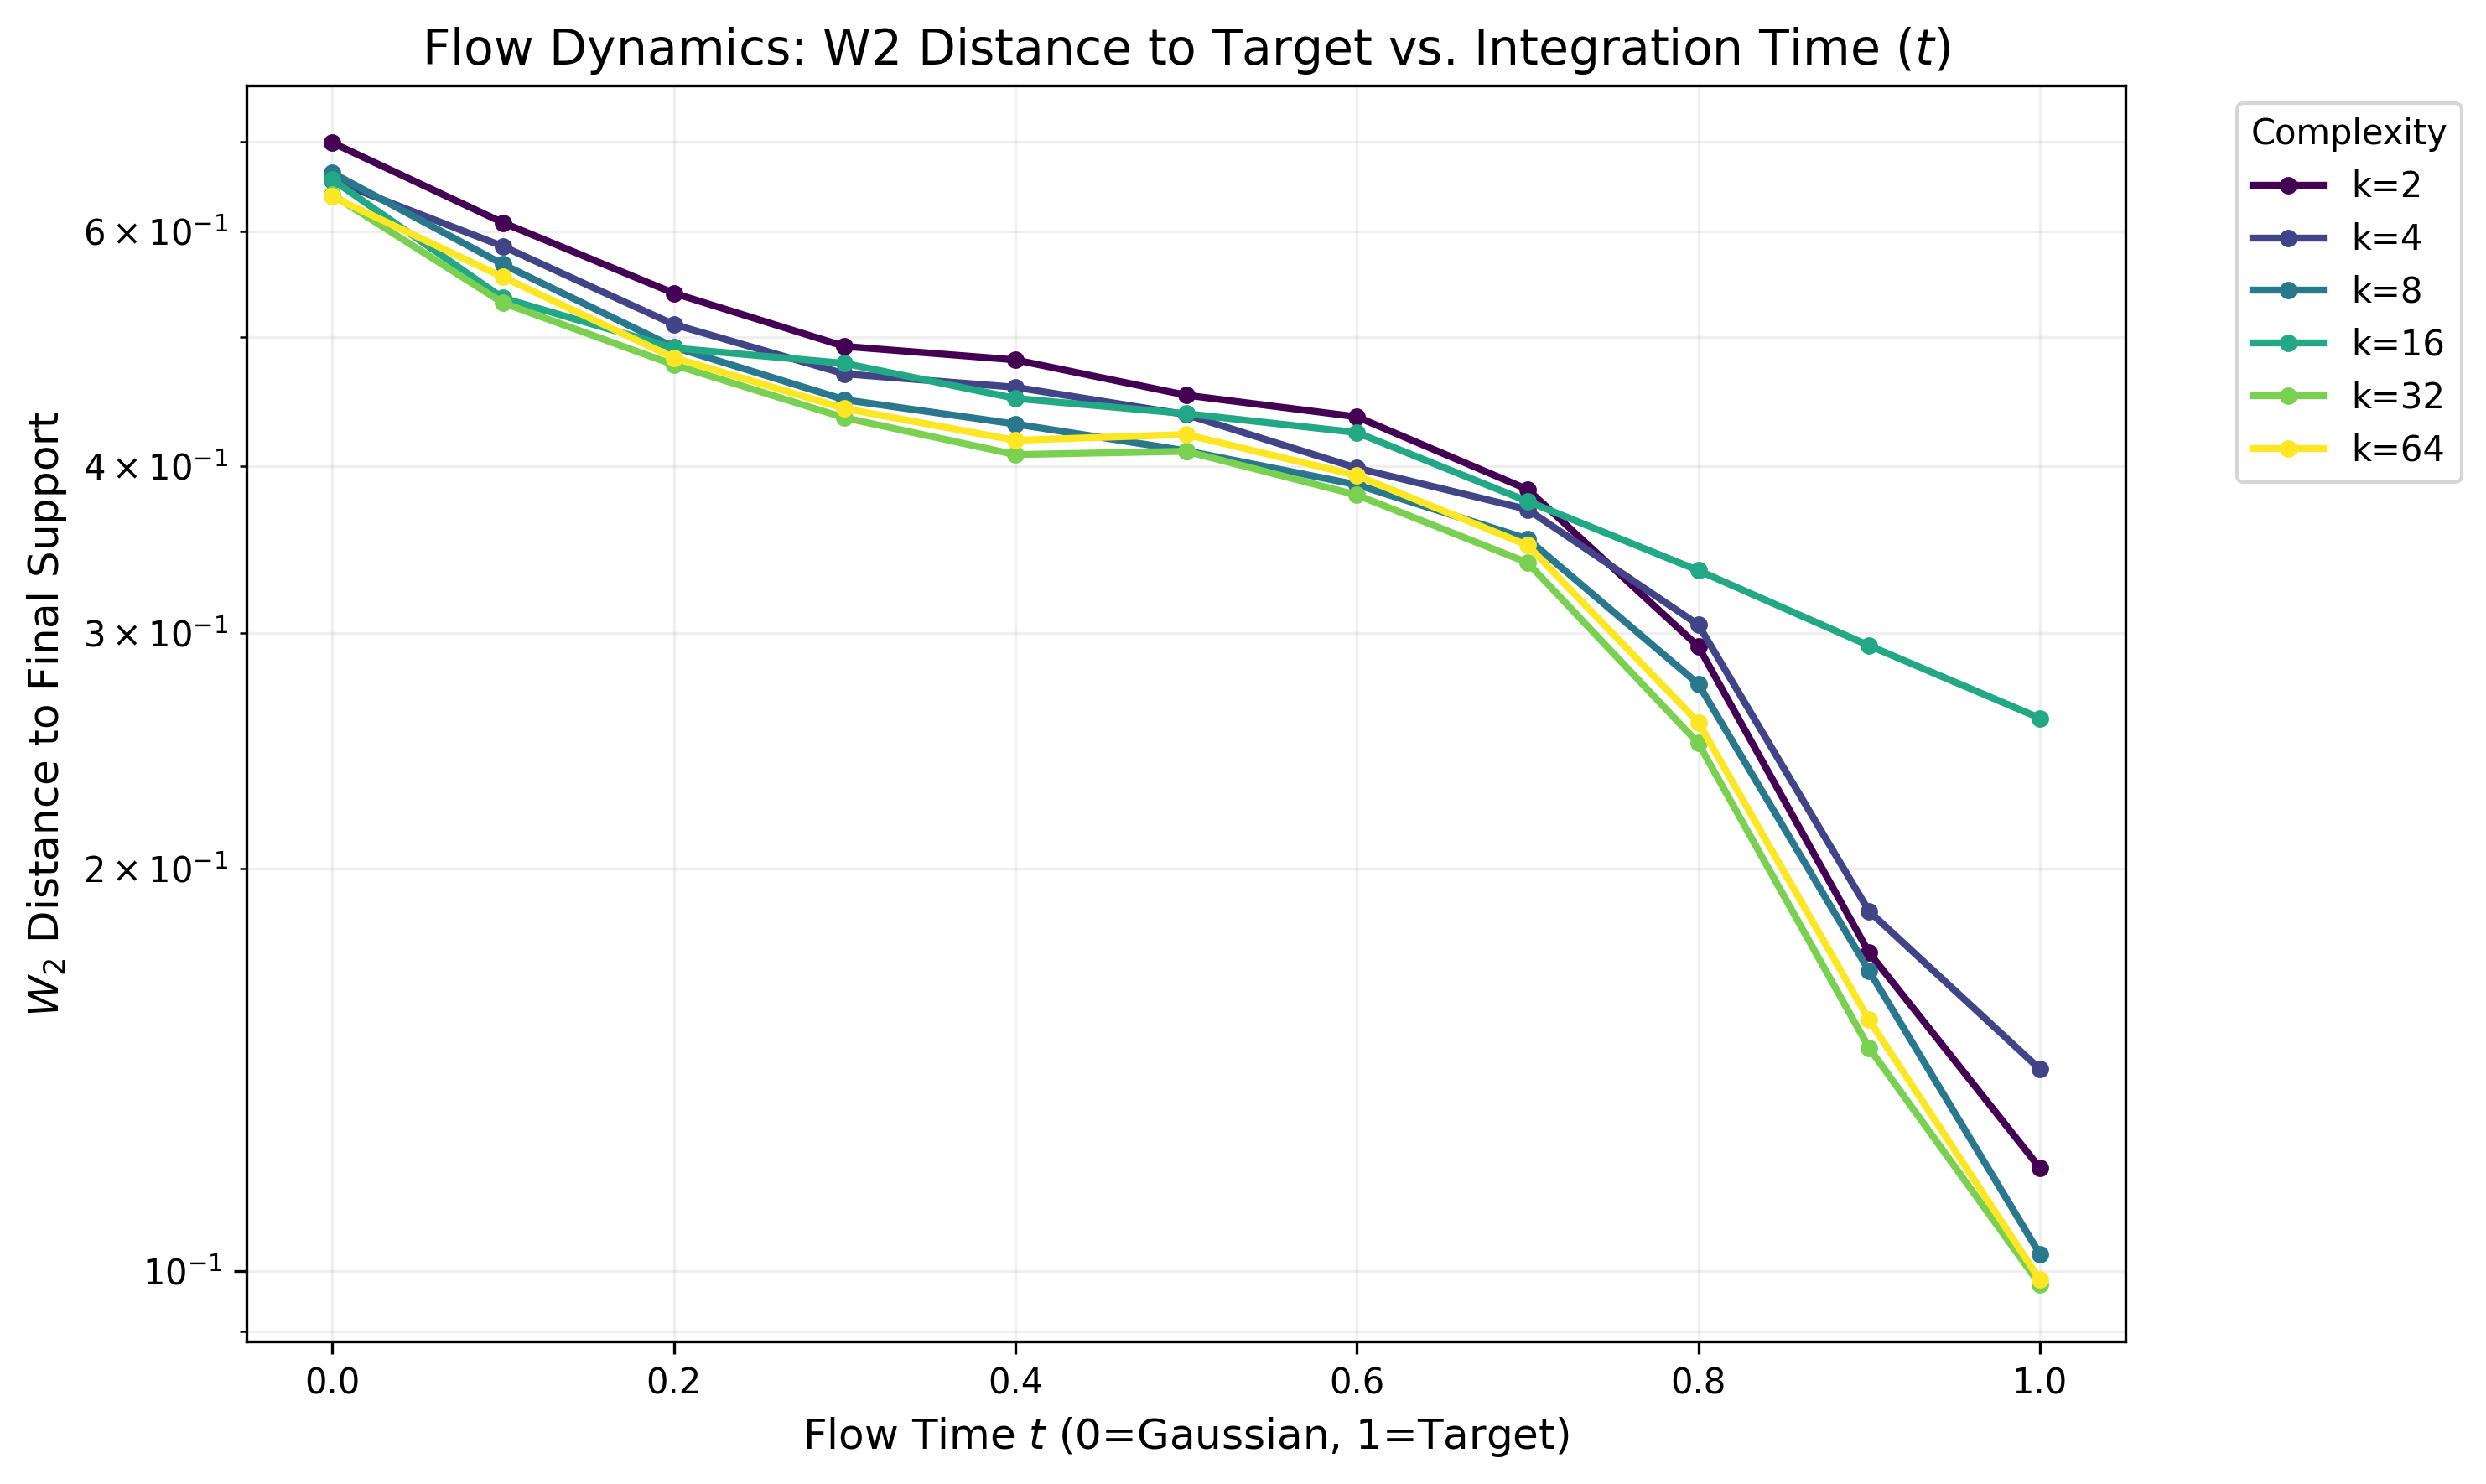

In [17]:
import torch

@torch.no_grad()
def calculate_w2_at_time_t(model, target_data, t_val, device, n_samples=2000):
    """
    Calculates W2 between the distribution at flow-time t 
    and the final target distribution.
    """
    model.eval()
    # 1. Start with Gaussian Noise
    x = torch.randn(n_samples, 2).to(device)
    
    # 2. Integrate the flow from 0 to t_val
    steps = 50
    dt = t_val / steps if t_val > 0 else 0
    
    for i in range(steps):
        if t_val == 0: break
        # Current time within the sub-integration [0, t_val]
        current_t = torch.ones(n_samples, device=device) * (i / steps) * t_val
        v = model(current_t, x)
        x = x + v * dt
    
    # 3. Compute W2 distance to the target support
    gen_np = x.cpu().numpy()
    # Sample a fresh subset of target data for comparison
    target_np = target_data[torch.randperm(len(target_data))[:n_samples]].cpu().numpy()
    
    M = ot.dist(gen_np, target_np, metric='sqeuclidean')
    return np.sqrt(ot.emd2([], [], M))

# --- Execution ---
plt.rcParams['figure.dpi'] = 300 # High DPI for clarity
t_grid = np.linspace(0, 1, 11) # 0.0, 0.1, ..., 1.0
colors = plt.cm.viridis(np.linspace(0, 1, len(k_values)))

plt.figure(figsize=(10, 6))

for i, k in enumerate(k_values):
    print(f"Calculating flow dynamics for k={k}...")
    w2_flow_dynamics = []
    
    for t in t_grid:
        dist = calculate_w2_at_time_t(models[k], datasets[k].data, t, device)
        w2_flow_dynamics.append(dist)
    
    plt.plot(t_grid, w2_flow_dynamics, marker='o', color=colors[i], 
             label=f"k={k}", lw=2, markersize=4)

plt.title("Flow Dynamics: W2 Distance to Target vs. Integration Time ($t$)", fontsize=14)
plt.xlabel("Flow Time $t$ (0=Gaussian, 1=Target)", fontsize=12)
plt.ylabel("$W_2$ Distance to Final Support", fontsize=12)
plt.yscale('log') # Log scale often reveals more about the final convergence
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend(title="Complexity", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Wiggly Circles' curvature

k     | Total Length    | Max Curvature  
---------------------------------------------
64    | 32.9960         | 667.3675       
32    | 17.6355         | 166.0217       
16    | 10.5469         | 40.6524        
8     | 7.6439          | 9.3061         
4     | 6.6605          | 2.4691         
2     | 6.3806          | 1.2840         


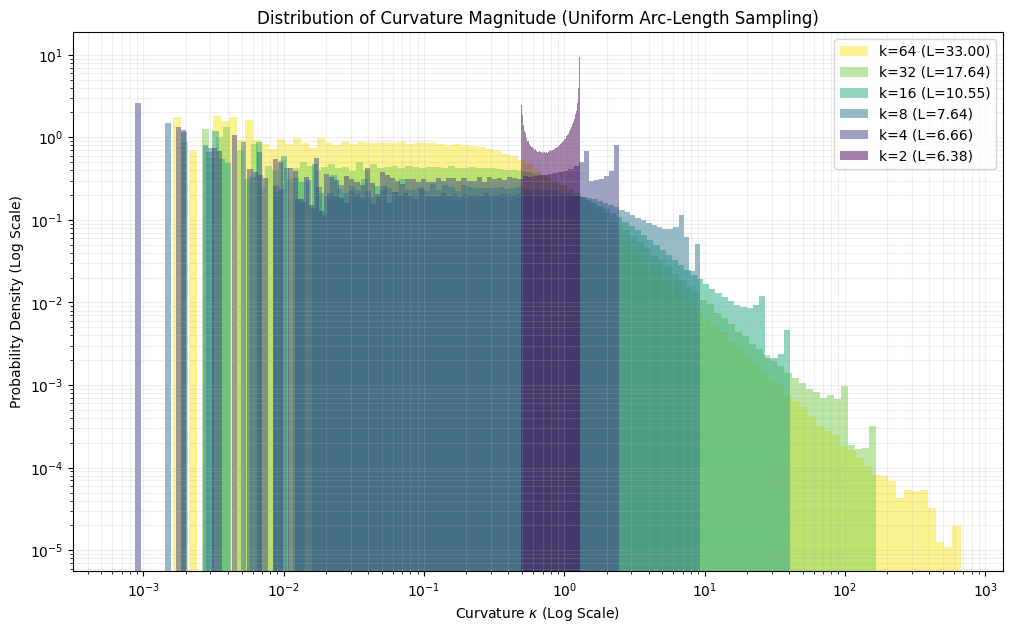

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.integrate import simpson

def calculate_geometry(k, R=1.0, A=0.125, n_points=50000):
    theta = np.linspace(0, 2*np.pi, n_points)
    
    # Derivatives of r(theta)
    r = R + A * np.sin(k * theta)
    r_prime = A * k * np.cos(k * theta)
    r_double_prime = -A * (k**2) * np.sin(k * theta)
    
    # 1. Calculate Arc Length
    # ds = sqrt(r^2 + (r')^2) d_theta
    ds_dt = np.sqrt(r**2 + r_prime**2)
    cumulative_length = np.concatenate([[0], np.cumsum(ds_dt[:-1] * np.diff(theta))])
    total_length = cumulative_length[-1]
    
    # 2. Calculate Exact Curvature |kappa|
    numerator = r**2 + 2*r_prime**2 - r*r_double_prime
    denominator = (r**2 + r_prime**2)**1.5
    kappa = np.abs(numerator / denominator)
    
    # 3. Uniform Sampling wrt Arc Length
    # Map uniform length samples back to theta space
    length_to_theta = interp1d(cumulative_length, theta, kind='linear')
    sampled_lengths = np.linspace(0, total_length, 5000) # 5k samples for the histogram
    sampled_thetas = length_to_theta(sampled_lengths)
    
    # Interpolate curvature at the uniform arc-length points
    kappa_at_samples = interp1d(theta, kappa, kind='linear')(sampled_thetas)
    
    return total_length, kappa_at_samples

# --- Execution ---
b_values = [1, 2, 3, 4, 5, 6]
k_values = [2**b for b in b_values]
colors = plt.cm.viridis(np.linspace(0, 1, len(k_values)))

plt.figure(figsize=(12, 7))

print(f"{'k':<5} | {'Total Length':<15} | {'Max Curvature':<15}")
print("-" * 45)

# Wrap enumerate in a list so reversed() can iterate over it backwards
for i, k in reversed(list(enumerate(k_values))):
    length, kappas = calculate_geometry(k)
    print(f"{k:<5} | {length:<15.4f} | {kappas.max():<15.4f}")
    
    plt.hist(kappas, bins=np.logspace(np.log10(min(kappas)), np.log10(max(kappas)), 100), 
             alpha=0.5, color=colors[i], label=f'k={k} (L={length:.2f})', density=True)

# Formatting the plot
plt.xscale('log') # Log scale for Curvature axis because range is ~1 to >1000
plt.yscale('log') # Log scale for Frequency to see the distribution of peaks
plt.title("Distribution of Curvature Magnitude (Uniform Arc-Length Sampling)")
plt.xlabel(r"Curvature $\kappa$ (Log Scale)")
plt.ylabel("Probability Density (Log Scale)")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()